# Manual FRED Series Workbench (Clean Workflow)

This notebook is designed for **reusable, one-series-at-a-time analysis**.

## Workflow
1. Set `SERIES_ID` and `CATEGORY` in the template cell.
2. Run core analysis (metadata, missingness, transformation diagnostics).
3. Optionally run similar-series search against FRED-MD.
4. Optionally append/update the markdown overview in `Data/analyzed/<category>.md`.

## Output Model (Markdown-First)
Saved outputs are stored in:
- `Data/analyzed/<category>.md` (one markdown table per category file)
- `Data/analyzed/images/` (saved level + transformed plots)

The markdown table stores one row per analyzed series and is updated in-place if the series already exists.

## Notes
- Core diagnostics evaluate **each transformation candidate first**, then test stationarity and variance stability on that transformed series.
- Optional steps are isolated so they are easy to comment out.

In [137]:
from __future__ import annotations

import json
import os
import re
import warnings
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from dotenv import load_dotenv
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning

plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)

In [138]:
# ---- project paths ----
NOTEBOOK_PATH = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_PATH

while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "Data" / "MD-dataset").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "Data" / "MD-dataset").exists():
    raise RuntimeError("Could not find project root. Open the notebook from inside the MLFCS_RLMM_26 repository.")

load_dotenv(PROJECT_ROOT / ".env")
FRED_API_KEY = os.getenv("FRED_API_KEY")
if not FRED_API_KEY:
    raise RuntimeError("FRED_API_KEY missing. Add it to .env in the repository root.")

DATA_ROOT     = PROJECT_ROOT / "Data"
ANALYZED_ROOT = DATA_ROOT / "analyzed"
ANALYZED_ROOT.mkdir(parents=True, exist_ok=True)

MD_ROOT       = PROJECT_ROOT / "Data" / "MD-dataset"
APPENDIX_ROOT = MD_ROOT / "appendix"

print("Project root:  ", PROJECT_ROOT)
print("FRED-MD root:  ", MD_ROOT)
print("Analyzed store:", ANALYZED_ROOT)


Project root:   C:\Users\olive\OneDrive\Dokumente\MASTER\MLFCS\MLFCS_RLMM_26
FRED-MD root:   C:\Users\olive\OneDrive\Dokumente\MASTER\MLFCS\MLFCS_RLMM_26\Data\MD-dataset
Analyzed store: C:\Users\olive\OneDrive\Dokumente\MASTER\MLFCS\MLFCS_RLMM_26\Data\analyzed


In [139]:
# ---- local FRED-MD loading ----
def read_csv_with_fallback(path: Path, encodings: list[str] | None = None, **kwargs) -> pd.DataFrame:
    if encodings is None:
        encodings = ["utf-8", "utf-8-sig", "cp1252", "latin-1"]

    last_error = None
    for encoding in encodings:
        try:
            return pd.read_csv(path, encoding=encoding, **kwargs)
        except UnicodeDecodeError as exc:
            last_error = exc

    raise UnicodeDecodeError(
        last_error.encoding if last_error else "utf-8",
        last_error.object if last_error else b"",
        last_error.start if last_error else 0,
        last_error.end if last_error else 1,
        f"Could not decode {path.name} with any of: {', '.join(encodings)}",
    )
    

def load_fred_md(md_root: Path = MD_ROOT):
    candidates = sorted(md_root.glob("*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No FRED-MD csv found in {md_root}")
    csv_path = candidates[0]
    raw = read_csv_with_fallback(csv_path)

    date_col = raw.columns[0]
    parsed = pd.to_datetime(raw[date_col], errors="coerce")
    first_date_idx = parsed.first_valid_index()
    if first_date_idx is None:
        raise ValueError("Could not find first valid date row in FRED-MD csv")

    tcodes = None
    if first_date_idx > 0:
        meta_rows = raw.iloc[:first_date_idx].copy()
        numeric_row = meta_rows.iloc[0, 1:]
        if numeric_row.notna().all():
            try:
                tcodes = {col: int(float(val)) for col, val in numeric_row.items()}
            except Exception:
                tcodes = None

    data = raw.iloc[first_date_idx:].copy()
    data[date_col] = pd.to_datetime(data[date_col])
    data = data.rename(columns={date_col: "date"}).set_index("date")
    for col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    appendix = None
    appendix_candidates = sorted((md_root / "appendix").glob("*.csv"))
    if appendix_candidates:
        appendix = read_csv_with_fallback(appendix_candidates[0])

    return {
        "csv_path": csv_path,
        "data": data,
        "tcodes": tcodes,
        "appendix": appendix,
    }

md_bundle = load_fred_md()
md_df = md_bundle["data"]
md_tcodes = md_bundle["tcodes"] or {}
md_appendix = md_bundle["appendix"]

print("Loaded FRED-MD:", md_bundle["csv_path"].name)
print("Shape:", md_df.shape)
print("Date range:", md_df.index.min().date(), "->", md_df.index.max().date())
print("Appendix loaded:", md_appendix is not None)

Loaded FRED-MD: 2026-02-MD.csv
Shape: (805, 126)
Date range: 1959-01-01 -> 2026-01-01
Appendix loaded: True


C:\Users\olive\AppData\Local\Temp\ipykernel_24024\1188587486.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(raw[date_col], errors="coerce")


In [140]:
# ---- FRED API helpers ----
BASE_URL = "https://api.stlouisfed.org/fred"
SESSION = requests.Session()


def fred_get(endpoint: str, **params):
    url = f"{BASE_URL}/{endpoint}"
    payload = {"api_key": FRED_API_KEY, "file_type": "json", **params}
    r = SESSION.get(url, params=payload, timeout=60)
    r.raise_for_status()
    data = r.json()
    if "error_code" in data:
        raise RuntimeError(f"FRED API error {data['error_code']}: {data.get('error_message')}")
    return data


def search_fred(text: str, limit: int = 20, order_by: str = "search_rank") -> pd.DataFrame:
    data = fred_get("series/search", search_text=text, limit=limit, order_by=order_by)
    return pd.DataFrame(data.get("seriess", []))


def get_series_meta(series_id: str) -> dict:
    data = fred_get("series", series_id=series_id)
    items = data.get("seriess", [])
    if not items:
        raise ValueError(f"No metadata found for {series_id}")
    return items[0]


def get_series_release(series_id: str) -> dict | None:
    data = fred_get("series/release", series_id=series_id)
    items = data.get("releases", [])
    return items[0] if items else None


def get_series_observations(series_id: str, observation_start=None, observation_end=None, frequency=None, aggregation_method=None, units=None):
    data = fred_get(
        "series/observations",
        series_id=series_id,
        observation_start=observation_start,
        observation_end=observation_end,
        frequency=frequency,
        aggregation_method=aggregation_method,
        units=units,
    )
    df = pd.DataFrame(data.get("observations", []))
    if df.empty:
        return df
    df["date"] = pd.to_datetime(df["date"])
    for c in ["realtime_start", "realtime_end"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df


def get_series_vintages(series_id: str, limit: int = 10000) -> list[str]:
    data = fred_get("series/vintagedates", series_id=series_id, limit=limit)
    return data.get("vintage_dates", [])

In [141]:
# ---- transform helpers ----
TCODE_LABELS = {
    1: "level",
    2: "first_difference",
    3: "second_difference",
    4: "log_level",
    5: "log_first_difference",
    6: "log_second_difference",
    7: "change_in_growth_rate",
}


def apply_tcode(series: pd.Series, tcode: int) -> pd.Series:
    s = series.astype(float).copy()
    if tcode == 1:
        return s
    if tcode == 2:
        return s.diff()
    if tcode == 3:
        return s.diff().diff()
    if tcode == 4:
        return np.log(s.where(s > 0))
    if tcode == 5:
        return np.log(s.where(s > 0)).diff()
    if tcode == 6:
        return np.log(s.where(s > 0)).diff().diff()
    if tcode == 7:
        g = s / s.shift(1) - 1.0
        return g.diff()
    raise ValueError(f"Unsupported tcode {tcode}")


def zscore(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    mu = s.mean()
    sigma = s.std()
    if pd.isna(sigma) or sigma == 0:
        return pd.Series(np.nan, index=s.index, name=f"{series.name}_zscore")
    out = (s - mu) / sigma
    out.name = f"{series.name}_zscore" if series.name else "zscore"
    return out


def variance_proxy(series: pd.Series) -> pd.Series:
    # Squared global z-score highlights high-variance episodes over time.
    z = zscore(series)
    vp = z.pow(2)
    vp.name = f"{series.name}_variance_proxy" if series.name else "variance_proxy"
    return vp


def annualized_change(series: pd.Series, periods: int, periods_per_year: int | None = None) -> pd.Series:
    if periods_per_year is None:
        periods_per_year = infer_periods_per_year(series)
    ratio = series / series.shift(periods)
    return ratio.pow(periods_per_year / periods) - 1


def infer_periods_per_year(series: pd.Series) -> int:
    idx = series.dropna().index
    if len(idx) < 3:
        return 12
    median_days = np.median(np.diff(idx.values).astype('timedelta64[D]').astype(int))
    if median_days <= 2:
        return 252
    if median_days <= 10:
        return 52
    if median_days <= 40:
        return 12
    if median_days <= 120:
        return 4
    return 1


def build_feature_frame(series: pd.Series) -> pd.DataFrame:
    ppy = infer_periods_per_year(series)
    out = pd.DataFrame(index=series.index)
    out["level"] = series
    out["diff_1"] = series.diff(1)
    out["diff_12"] = series.diff(12 if ppy >= 12 else min(ppy, len(series)-1))
    out["pct_change_1"] = series.pct_change(1)
    out["pct_change_12"] = series.pct_change(12 if ppy >= 12 else min(ppy, len(series)-1))
    if ppy >= 12:
        out["ann_3m"] = annualized_change(series, 3, ppy)
        out["ann_6m"] = annualized_change(series, 6, ppy)
    elif ppy == 4:
        out["ann_2q"] = annualized_change(series, 2, ppy)
        out["ann_4q"] = annualized_change(series, 4, ppy)
    out["zscore"] = zscore(series)
    out["variance_proxy"] = variance_proxy(series)
    out["dev_from_36_mean"] = series - series.rolling(min(36, max(12, len(series)//4))).mean()
    return out

In [142]:
# ---- summary / diagnostics ----
def _clean_for_tests(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()


def missing_intervals(series: pd.Series) -> pd.DataFrame:
    """Return contiguous missing-value intervals with start/end/length."""
    s = pd.to_numeric(series, errors="coerce")
    miss = s.isna()
    if not miss.any():
        return pd.DataFrame(columns=["start", "end", "n_missing"])

    grp = (miss != miss.shift()).cumsum()
    rows = []
    for _, idx in s[miss].groupby(grp[miss]).groups.items():
        block_idx = s.loc[idx].index
        rows.append({
            "start": block_idx.min(),
            "end": block_idx.max(),
            "n_missing": len(block_idx),
        })
    return pd.DataFrame(rows).sort_values("start").reset_index(drop=True)


def format_missing_summary(series: pd.Series) -> str:
    n_obs = int(len(series))
    n_missing = int(series.isna().sum())
    share = float(series.isna().mean()) if n_obs else np.nan
    miss_tbl = missing_intervals(series)

    lines = [
        f"n_obs={n_obs}"
        f"n_missing={n_missing}"
        f"share_missing={share:.2%}" if np.isfinite(share) else "share_missing=nan"
    ]

    if miss_tbl.empty:
        lines.append("intervals=none")
    else:
        lines.extend(
            f"{r['start'].date()} -> {r['end'].date()} ({int(r['n_missing'])})"
            for _, r in miss_tbl.iterrows()
        )

    body = "<br>".join(lines)
    return f"<div style=\"display:block; width:max-content; min-width:580px; max-width:none; white-space:normal;\">{body}</div>"


def show_missing_report(series: pd.Series, max_rows: int = 20):
    tbl = missing_intervals(series)
    if tbl.empty:
        display(Markdown("No missing intervals."))
        return tbl
    display(Markdown(f"Missing intervals: {len(tbl)} blocks"))
    display(tbl.head(max_rows))
    if len(tbl) > max_rows:
        display(Markdown(f"Showing first {max_rows} of {len(tbl)} missing intervals."))
    return tbl


def summarize_series(series_id: str, obs_df: pd.DataFrame, meta: dict | None = None, release: dict | None = None, vintages: list[str] | None = None) -> pd.DataFrame:
    s = obs_df.set_index("date")["value"].sort_index() if "date" in obs_df.columns else obs_df["value"].sort_index()
    total = len(s)
    missing = int(s.isna().sum())
    missing_tbl = missing_intervals(s)

    out = {
        "series_id": series_id,
        "title": (meta or {}).get("title"),
        "frequency": (meta or {}).get("frequency"),
        "units": (meta or {}).get("units"),
        "seasonal_adjustment": (meta or {}).get("seasonal_adjustment"),
        "observation_start": (meta or {}).get("observation_start"),
        "observation_end": (meta or {}).get("observation_end"),
        "n_obs": total,
        "n_missing": missing,
        "missing_share": round(missing / total, 4) if total else np.nan,
        "missing_blocks": len(missing_tbl),
        "max_missing_block": int(missing_tbl["n_missing"].max()) if not missing_tbl.empty else 0,
        "first_valid": s.first_valid_index(),
        "last_valid": s.last_valid_index(),
        "period_covered": f"{s.first_valid_index().date()} -> {s.last_valid_index().date()}" if s.notna().any() else "no_valid_values",
        "source": (release or {}).get("link") or (release or {}).get("name"),
        "release_name": (release or {}).get("name"),
        "notes": (meta or {}).get("notes"),
        "n_vintage_dates": len(vintages or []),
        "revision_behavior_hint": "has_multiple_vintages" if len(vintages or []) > 1 else "little_or_no_revision_signal",
    }
    return pd.DataFrame([out]).T.rename(columns={0: "value"})


def adf_result(series: pd.Series) -> dict:
    s = _clean_for_tests(series)
    if len(s) < 20 or s.nunique() < 2:
        return {"error": "too_few_or_constant"}
    stat, pvalue, usedlag, nobs, crit, _ = adfuller(s, autolag="AIC")
    return {
        "stat": float(stat),
        "pvalue": float(pvalue),
        "usedlag": int(usedlag),
        "nobs": int(nobs),
        "critical_values": crit,
        "conclusion_5pct": "stationary" if pvalue < 0.05 else "fails_to_reject_unit_root",
    }


def kpss_result(series: pd.Series) -> dict:
    s = _clean_for_tests(series)
    if len(s) < 20 or s.nunique() < 2:
        return {"error": "too_few_or_constant"}
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", InterpolationWarning)
            stat, pvalue, lags, crit = kpss(s, regression="c", nlags="auto")
        return {
            "stat": float(stat),
            "pvalue": float(pvalue),
            "lags": int(lags),
            "critical_values": crit,
            "conclusion_5pct": "fails_to_reject_stationarity" if pvalue >= 0.05 else "rejects_stationarity",
        }
    except Exception as e:
        return {"error": str(e)}


def arch_result(series: pd.Series, nlags: int = 12) -> dict:
    s = _clean_for_tests(series)
    if len(s) < max(30, nlags * 3) or s.nunique() < 2:
        return {"error": "too_few_or_constant"}
    centered = s - s.mean()
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(centered, nlags=nlags)
    return {
        "lm_stat": float(lm_stat),
        "lm_pvalue": float(lm_pvalue),
        "f_stat": float(f_stat),
        "f_pvalue": float(f_pvalue),
        "conclusion_5pct": "heteroskedastic" if lm_pvalue < 0.05 else "no_strong_arch_effect",
    }


def ljungbox_result(series: pd.Series, lag: int = 12) -> dict:
    s = _clean_for_tests(series)
    if len(s) < 30 or s.nunique() < 2:
        return {"error": "too_few_or_constant"}
    use_lag = min(lag, max(1, len(s) // 5))
    try:
        out = acorr_ljungbox(s, lags=[use_lag], return_df=True)
        pvalue = float(out["lb_pvalue"].iloc[0])
        return {
            "lag": int(use_lag),
            "pvalue": pvalue,
            "conclusion_5pct": "no_strong_autocorrelation" if pvalue >= 0.05 else "autocorrelation_detected",
        }
    except Exception as e:
        return {"error": str(e)}


def evaluate_tcode_candidate(series: pd.Series, tcode: int) -> dict:
    """Apply one tcode and evaluate diagnostics on the transformed series."""
    try:
        transformed = apply_tcode(series, tcode)
        cleaned = _clean_for_tests(transformed)
    except Exception as exc:
        return {
            "tcode": tcode,
            "label": TCODE_LABELS.get(tcode, "unknown"),
            "can_apply": 0,
            "error": str(exc),
        }

    adf = adf_result(cleaned)
    kpss_out = kpss_result(cleaned)
    arch = arch_result(cleaned)
    lb = ljungbox_result(cleaned)

    adf_stationary = adf.get("conclusion_5pct") == "stationary"
    kpss_stationary = kpss_out.get("conclusion_5pct") == "fails_to_reject_stationarity"
    stationarity_ok = int(adf_stationary and kpss_stationary)
    variance_ok = int(arch.get("conclusion_5pct") == "no_strong_arch_effect")
    autocorr_ok = int(lb.get("conclusion_5pct") == "no_strong_autocorrelation")

    return {
        "tcode": tcode,
        "label": TCODE_LABELS.get(tcode, "unknown"),
        "can_apply": 1,
        "n_obs": int(len(cleaned)),
        "adf_pvalue": adf.get("pvalue"),
        "kpss_pvalue": kpss_out.get("pvalue"),
        "arch_pvalue": arch.get("lm_pvalue"),
        "ljungbox_pvalue": lb.get("pvalue"),
        "stationarity_ok": stationarity_ok,
        "variance_ok": variance_ok,
        "autocorr_ok": autocorr_ok,
        "overall_ok": int(stationarity_ok and variance_ok),
    }


def review_tcodes(series: pd.Series, do_plots: bool = False) -> pd.DataFrame:
    s = _clean_for_tests(series)
    rows = []
    for tcode in sorted(TCODE_LABELS):
        result = evaluate_tcode_candidate(s, tcode)
        rows.append(result)
        if do_plots and result.get("can_apply") == 1:
            transformed = _clean_for_tests(apply_tcode(s, tcode))
            transformed.name = f"{series.name}_tcode{tcode}"
            plot_series(transformed, f"{series.name} | tcode {tcode} ({TCODE_LABELS[tcode]})")

    out = pd.DataFrame(rows).set_index("tcode")
    if out.empty:
        return out

    out["recommended"] = 0
    candidates = out[out["can_apply"] == 1].copy()
    if not candidates.empty:
        candidates = candidates.sort_values(
            by=["overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"],
            ascending=False,
        )
        out.loc[candidates.index[0], "recommended"] = 1

    return out


def recommend_tcode(series: pd.Series) -> pd.DataFrame:
    review = review_tcodes(series, do_plots=False)
    if review.empty:
        return pd.DataFrame(columns=["label", "can_apply", "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "suggested"])

    cols = ["label", "can_apply", "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended"]
    out = review[cols].rename(columns={"recommended": "suggested"})
    return out


def run_basic_tests(series: pd.Series) -> pd.DataFrame:
    """Baseline tests on level and diff(1), mostly for context."""
    rows = {
        "ADF_level": adf_result(series),
        "KPSS_level": kpss_result(series),
        "ARCH_level": arch_result(series),
        "LjungBox_level": ljungbox_result(series),
        "ADF_diff1": adf_result(series.diff()),
        "KPSS_diff1": kpss_result(series.diff()),
        "ARCH_diff1": arch_result(series.diff()),
        "LjungBox_diff1": ljungbox_result(series.diff()),
    }
    return pd.DataFrame(rows).T


def build_stationarity_comment(series: pd.Series) -> str:
    summary = review_tcodes(series, do_plots=False)
    rec = summary[summary.get("recommended", 0) == 1]
    miss_text = format_missing_summary(series)
    if rec.empty:
        return f"No clear recommended tcode. {miss_text}"
    tcode = int(rec.index[0])
    row = rec.iloc[0]
    return (
        f"Recommended tcode {tcode} ({row['label']}); stationarity_ok={int(row['stationarity_ok'])}, "
        f"variance_ok={int(row['variance_ok'])}, autocorr_ok={int(row['autocorr_ok'])}. {miss_text}"
    )


def show_core_summary(series_id: str, obs: pd.DataFrame, meta: dict, release: dict | None, vintages: list[str]):
    summary_tbl = summarize_series(series_id, obs, meta, release, vintages)
    display(Markdown(f"### {series_id}: {meta.get('title', '')}"))
    display(summary_tbl.loc[[
        "period_covered", "frequency", "seasonal_adjustment", "units", "n_obs", "n_missing",
        "missing_share", "missing_blocks", "max_missing_block", "n_vintage_dates",
    ]])

In [143]:
# ---- plotting helpers ----
IMAGES_ROOT = ANALYZED_ROOT / "images"
IMAGES_ROOT.mkdir(parents=True, exist_ok=True)


def _slug(value: str) -> str:
    value = str(value).strip().lower()
    value = re.sub(r"[^a-z0-9]+", "-", value)
    return value.strip("-")


def _plot_to_file(series: pd.Series, out_path: Path, title: str, y0: float | None = None):
    fig, ax = plt.subplots(figsize=(12, 4))
    series.plot(ax=ax, title=title)
    if y0 is not None:
        ax.axhline(y0, linestyle="--", linewidth=1)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)


def plot_series(series: pd.Series, title: str | None = None):
    ax = series.plot(title=title or series.name)
    ax.axhline(series.mean(), linestyle="--", linewidth=1)
    plt.show()


def plot_diff(series: pd.Series, periods: int = 1, title: str | None = None):
    d = series.diff(periods)
    ax = d.plot(title=title or f"{series.name} diff({periods})")
    ax.axhline(0, linestyle="--", linewidth=1)
    plt.show()
    return d


def plot_zscore(series: pd.Series, title: str | None = None):
    z = zscore(series)
    ax = z.plot(title=title or f"{series.name} z-score (full sample)")
    for y in [-2, 0, 2]:
        ax.axhline(y, linestyle="--", linewidth=1)
    plt.show()
    return z


def plot_variance_proxy(series: pd.Series, title: str | None = None):
    vp = variance_proxy(series)
    ax = vp.plot(title=title or f"{series.name} variance proxy (z-score squared)")
    ax.axhline(vp.mean(), linestyle="--", linewidth=1)
    plt.show()
    return vp


def plot_all_basic(series: pd.Series):
    plot_series(series, f"{series.name} level")
    d1 = plot_diff(series, 1, f"{series.name} first difference")
    plot_zscore(d1.dropna(), f"{series.name} first-difference z-score")
    plot_variance_proxy(d1.dropna(), f"{series.name} variance proxy from first difference")


def save_required_plots(series: pd.Series, series_id: str, category: str, tcode1: int, tcode2: int | None = None) -> dict:
    """Save level/tcode plots and return markdown image links for the overview table."""
    category_slug = _slug(category) or "uncategorized"
    series_slug = _slug(series_id)
    stem = f"{category_slug}_{series_slug}"

    level_file = IMAGES_ROOT / f"{stem}_level.png"
    _plot_to_file(series, level_file, f"{series_id} level", y0=float(series.mean()))

    t1 = _clean_for_tests(apply_tcode(series, int(tcode1)))
    t1_file = IMAGES_ROOT / f"{stem}_tcode{int(tcode1)}.png"
    _plot_to_file(t1, t1_file, f"{series_id} tcode {int(tcode1)} ({TCODE_LABELS.get(int(tcode1), 'unknown')})", y0=0.0)

    t2_file = None
    if tcode2 is not None and str(tcode2).strip() != "":
        t2 = _clean_for_tests(apply_tcode(series, int(tcode2)))
        t2_file = IMAGES_ROOT / f"{stem}_tcode{int(tcode2)}.png"
        _plot_to_file(t2, t2_file, f"{series_id} tcode {int(tcode2)} ({TCODE_LABELS.get(int(tcode2), 'unknown')})", y0=0.0)

    def _md_img(path: Path | None) -> str:
        if path is None:
            return ""
        return f"<img src=\"images/{path.name}\" alt=\"{path.stem}\" style=\"display:block; width:260px; min-width:500px; max-width:500px; height:260px; object-fit:contain;\" />"

    return {
        "level_path": level_file,
        "tcode1_path": t1_file,
        "tcode2_path": t2_file,
        "level_md": _md_img(level_file),
        "tcode1_md": _md_img(t1_file),
        "tcode2_md": _md_img(t2_file),
    }

In [144]:
# ---- FRED-MD comparison helpers ----
# find_similar_in_fred_md scores each FRED-MD series two ways:
# 1. Text score  (weight 0.7): SequenceMatcher ratio on series_id + title vs appendix description.
# 2. Corr score  (weight 0.3): Pearson on first-differenced, z-scored versions of both series.
#    - Both sides are detrended (first diff) and scaled (z-score) before correlating.
#    - This removes spurious 'both trending up' correlations that inflate raw-level similarity.
#    - Correlation is only a tiebreaker; text overlap is the primary signal.

def _appendix_text_columns(df: pd.DataFrame):
    return [c for c in df.columns if df[c].dtype == object]


def _corr_with_md(input_series: pd.Series, md_series_id: str) -> float | None:
    if md_series_id not in md_df.columns:
        return None
    md_raw = md_df[md_series_id].dropna()
    # First-difference and z-score both series to remove trend and scale effects.
    def _prep(s: pd.Series) -> pd.Series:
        d = s.diff().dropna()
        mu, sigma = d.mean(), d.std()
        if sigma == 0 or pd.isna(sigma):
            return d
        return (d - mu) / sigma
    inp = _prep(input_series)
    md_s = _prep(md_raw)
    common = inp.index.intersection(md_s.index)
    if len(common) < 12:
        return None
    try:
        c = float(inp.loc[common].corr(md_s.loc[common]))
        return c if np.isfinite(c) else None
    except Exception:
        return None


def find_similar_in_fred_md(input_series: pd.Series | None = None, series_id: str = "", title: str | None = None, top_n: int = 10) -> pd.DataFrame:
    candidates = []

    # Exact ID match always scores 1.
    if series_id and series_id in md_df.columns:
        corr = _corr_with_md(input_series, series_id) if input_series is not None else None
        candidates.append({
            "md_series": series_id,
            "tcode": md_tcodes.get(series_id),
            "text_score": 1.0,
            "corr": round(corr, 3) if corr is not None else None,
            "combined_score": 1.0,
            "match_type": "exact_id",
            "appendix_preview": "",
        })

    if md_appendix is not None:
        query_text = f"{series_id} {title or ''}".strip().lower()
        obj_cols = _appendix_text_columns(md_appendix)
        for _, row in md_appendix.iterrows():
            parts = [str(row[c]) for c in obj_cols if pd.notna(row[c])]
            blob = " | ".join(parts)
            text_score = SequenceMatcher(None, query_text, blob.lower()).ratio()

            md_series_id = None
            for val in row.values:
                if isinstance(val, str) and val in md_df.columns:
                    md_series_id = val
                    break

            corr = _corr_with_md(input_series, md_series_id) if (input_series is not None and md_series_id) else None
            corr_component = abs(corr) if corr is not None else 0.0
            # Text dominates (0.7); correlation is a tiebreaker (0.3).
            combined = 0.7 * text_score + 0.3 * corr_component

            candidates.append({
                "md_series": md_series_id,
                "tcode": md_tcodes.get(md_series_id) if md_series_id else None,
                "text_score": round(text_score, 3),
                "corr": round(corr, 3) if corr is not None else None,
                "combined_score": round(combined, 3),
                "match_type": "text+corr",
                "appendix_preview": blob[:160],
            })

    if not candidates:
        return pd.DataFrame()

    out = (
        pd.DataFrame(candidates)
        .sort_values("combined_score", ascending=False)
        .drop_duplicates(subset=["md_series"])
        .head(top_n)
        .reset_index(drop=True)
    )
    return out

In [145]:
# ---- markdown-first overview helpers ----
OVERVIEW_ROOT = ANALYZED_ROOT
OVERVIEW_ROOT.mkdir(parents=True, exist_ok=True)


def normalize_category(category: str | None) -> str:
    if category is None:
        return "uncategorized"
    cleaned = _slug(str(category))
    return cleaned if cleaned else "uncategorized"


OVERVIEW_COLUMNS = [
    "Series_ID",
    "Description",
    "Interval Covered",
    "Frequency",
    "Missing Values Summary",
    "Suggested TCode 1",
    "Suggested TCode 2",
    "Level Plot",
    "TCode 1 Plot",
    "TCode 2 Plot",
]


def _escape_md_cell(value) -> str:
    if value is None:
        return ""
    text = str(value).replace("\n", " ").strip()
    return text.replace("|", "\\|")


def _format_description_cell(text: str) -> str:
    raw = str(text or "").strip()
    if not raw:
        return ""
    safe = (
        raw.replace("&", "&amp;")
        .replace("<", "&lt;")
        .replace(">", "&gt;")
        .replace("\r\n", "\n")
        .replace("\r", "\n")
    )
    safe = "<br>".join(safe.split("\n"))
    return f"<div style=\"display:block; min-width:500px; max-width:800px; white-space:normal;\">{safe}</div>"


def _split_md_row(line: str) -> list[str]:
    parts = [p.strip() for p in line.strip().strip("|").split("|")]
    return [p.replace("\\|", "|") for p in parts]


def _is_separator_row(cells: list[str]) -> bool:
    if not cells:
        return False
    return all(set(c.replace(" ", "")) <= {"-", ":"} and c != "" for c in cells)


def _read_existing_rows(md_path: Path) -> list[dict]:
    if not md_path.exists():
        return []

    lines = md_path.read_text(encoding="utf-8").splitlines()
    table_lines = [ln for ln in lines if ln.strip().startswith("|") and ln.strip().endswith("|")]
    if len(table_lines) < 2:
        return []

    header = _split_md_row(table_lines[0])
    rows = []
    for ln in table_lines[1:]:
        cells = _split_md_row(ln)
        if _is_separator_row(cells):
            continue
        if len(cells) != len(header):
            continue
        row = {h: c for h, c in zip(header, cells)}
        if row.get("Series_ID"):
            rows.append(row)
    return rows


def _write_category_markdown(category: str, rows: list[dict]) -> Path:
    category_slug = normalize_category(category)
    md_path = OVERVIEW_ROOT / f"{category_slug}.md"

    title = f"# Analyzed Series - {category_slug}"
    intro = "This file is auto-managed by append_series_to_markdown_overview()."

    header = "| " + " | ".join(OVERVIEW_COLUMNS) + " |"
    sep = "| " + " | ".join(["---"] * len(OVERVIEW_COLUMNS)) + " |"
    body = []
    for row in rows:
        body.append("| " + " | ".join(_escape_md_cell(row.get(c, "")) for c in OVERVIEW_COLUMNS) + " |")

    content_lines = [title, "", intro, "", header, sep, *body, ""]
    md_path.write_text("\n".join(content_lines), encoding="utf-8")
    return md_path


def append_series_to_markdown_overview(
    series_id: str,
    category: str,
    description: str,
    tcode1: int,
    tcode2: int | None = None,
    obs_df: pd.DataFrame | None = None,
    meta: dict | None = None,
    release: dict | None = None,
    vintages: list[str] | None = None,
) -> Path:
    """
    Upsert one series row into Data/analyzed/<category>.md and save required plots.

    Manual inputs: description, tcode1, tcode2
    Auto fields: interval/frequency/missing summary/plot links
    """
    category_slug = normalize_category(category)
    sid = str(series_id).strip().upper()

    if obs_df is None:
        obs_df = get_series_observations(sid)
    if meta is None:
        meta = get_series_meta(sid)
    if release is None:
        release = get_series_release(sid)
    if vintages is None:
        vintages = get_series_vintages(sid)

    if obs_df.empty:
        raise ValueError(f"No observations found for {sid}")

    obs = obs_df.copy().sort_values("date")
    series = obs.set_index("date")["value"].sort_index()
    series.name = sid

    summary_tbl = summarize_series(sid, obs, meta, release, vintages)
    period_covered = str(summary_tbl.loc["period_covered", "value"]) if "period_covered" in summary_tbl.index else ""
    frequency = str(meta.get("frequency", ""))
    seasonal_adjustment = str(meta.get("seasonal_adjustment", "")).strip()
    if seasonal_adjustment:
        frequency = f"{frequency}<br><span style=\"font-size:0.92em; color:#555;\">{seasonal_adjustment}</span>" if frequency else f"{seasonal_adjustment}"
    missing_summary = format_missing_summary(series)

    plot_info = save_required_plots(series, sid, category_slug, int(tcode1), int(tcode2) if tcode2 is not None and str(tcode2).strip() != "" else None)

    row = {
        "Series_ID": sid,
        "Description": _format_description_cell(description),
        "Interval Covered": period_covered,
        "Frequency": frequency,
        "Missing Values Summary": missing_summary,
        "Suggested TCode 1": int(tcode1),
        "Suggested TCode 2": "" if tcode2 is None or str(tcode2).strip() == "" else int(tcode2),
        "Level Plot": plot_info["level_md"],
        "TCode 1 Plot": plot_info["tcode1_md"],
        "TCode 2 Plot": plot_info["tcode2_md"],
    }

    md_path = OVERVIEW_ROOT / f"{category_slug}.md"
    rows = _read_existing_rows(md_path)

    upserted = False
    for i, existing in enumerate(rows):
        if str(existing.get("Series_ID", "")).upper() == sid:
            rows[i] = row
            upserted = True
            break
    if not upserted:
        rows.append(row)

    rows = sorted(rows, key=lambda r: str(r.get("Series_ID", "")))
    md_path = _write_category_markdown(category_slug, rows)
    print(f"Updated markdown overview: {md_path.relative_to(PROJECT_ROOT)}")
    return md_path


def show_category_overview(category: str):
    category_slug = normalize_category(category)
    md_path = OVERVIEW_ROOT / f"{category_slug}.md"
    if not md_path.exists():
        display(Markdown(f"No overview yet for category '{category_slug}'."))
        return
    display(Markdown(md_path.read_text(encoding="utf-8")))


def show_overview_index():
    files = sorted(OVERVIEW_ROOT.glob("*.md"))
    if not files:
        display(Markdown("No category markdown files in Data/analyzed yet."))
        return
    lines = ["### Available category overviews", ""]
    for p in files:
        lines.append(f"- {p.relative_to(PROJECT_ROOT)}")
    display(Markdown("\n".join(lines)))


def legacy_save_series_package(*args, **kwargs):
    raise RuntimeError(
        "legacy_save_series_package is disabled in the markdown-first workflow. "
        "Use append_series_to_markdown_overview(...) instead."
    )

### GFDEBTN: Federal Debt: Total Public Debt

,value
period_covered,1966-01-01 -> 2025-10-01
frequency,"Quarterly, End of Period"
seasonal_adjustment,Not Seasonally Adjusted
units,Millions of Dollars
n_obs,240
n_missing,0
missing_share,0.0
missing_blocks,0
max_missing_block,0
n_vintage_dates,117


No missing intervals.

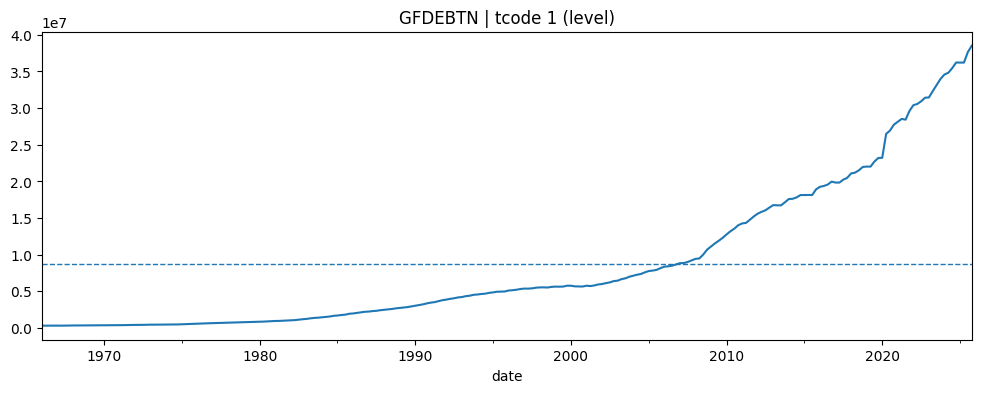

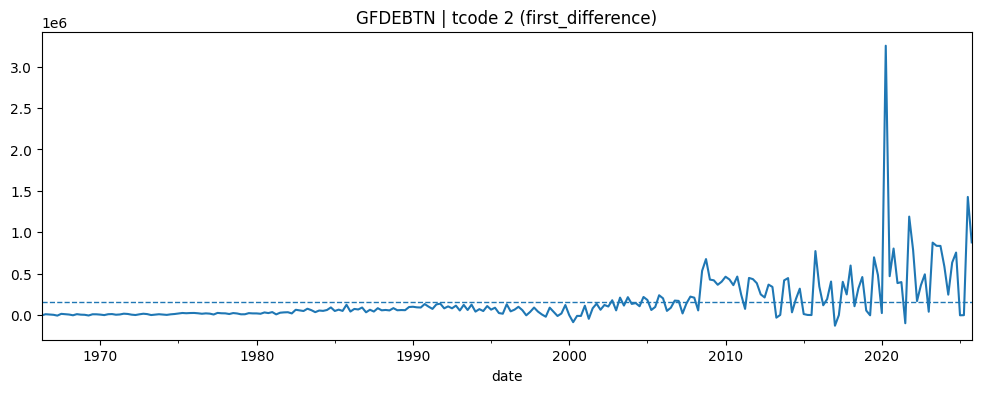

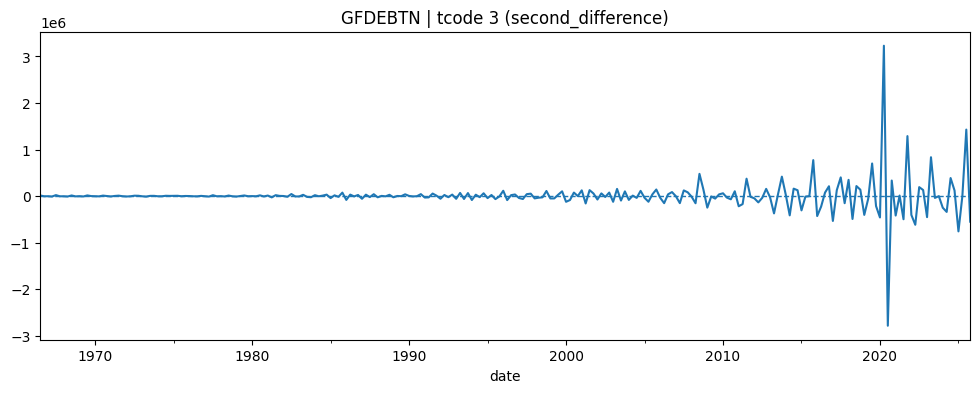

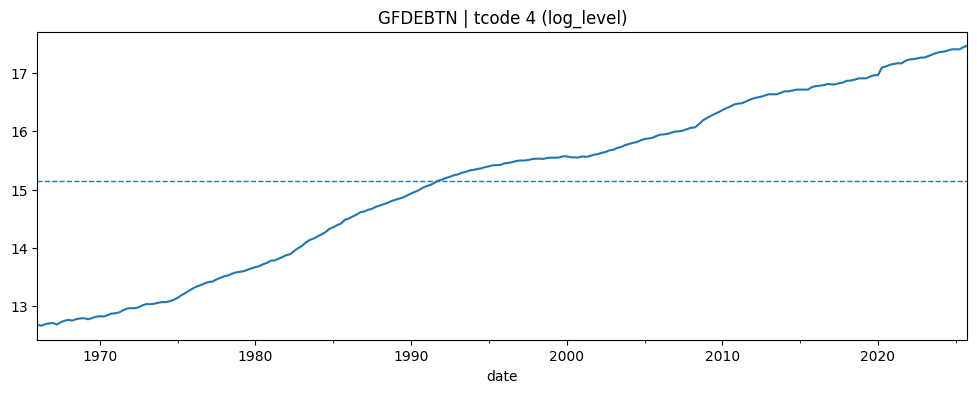

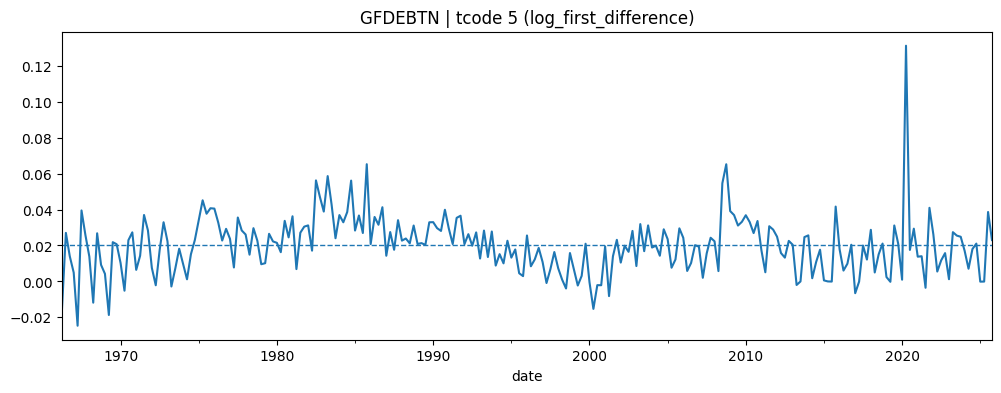

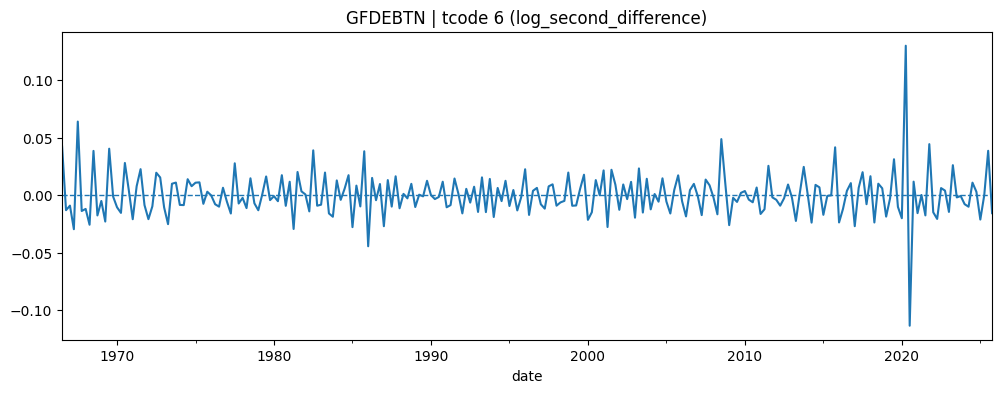

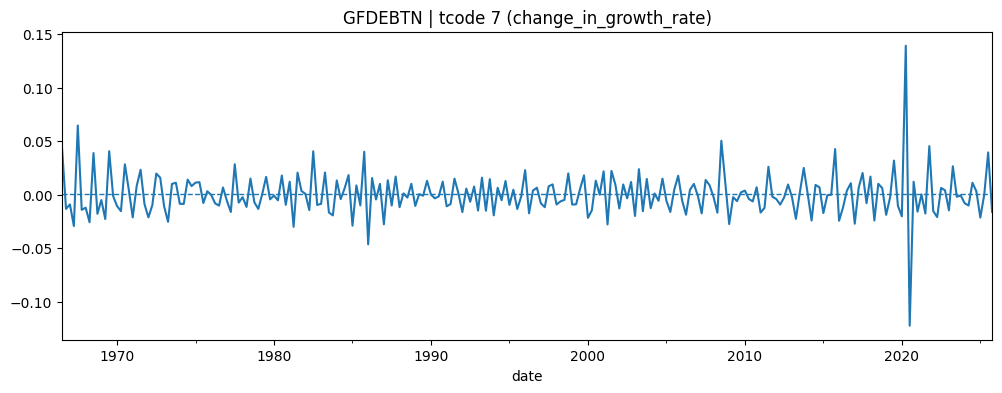

### Transformation Diagnostics

,label,n_obs,adf_pvalue,kpss_pvalue,arch_pvalue,stationarity_ok,variance_ok,autocorr_ok,overall_ok,recommended
tcode,,,,,,,,,,
1,level,240,1.000000e+00,0.01,6.832957e-42,0,0,0,0,0
2,first_difference,239,8.009950e-01,0.01,9.782196e-01,0,1,0,0,0
3,second_difference,238,4.470757e-08,0.10,3.763269e-12,1,0,0,0,0
4,log_level,240,7.296718e-01,0.01,5.564119e-42,0,0,0,0,0
5,log_first_difference,239,1.496143e-02,0.10,9.999277e-01,1,1,0,1,1
6,log_second_difference,238,4.915223e-09,0.10,2.880982e-11,1,0,0,0,0
7,change_in_growth_rate,238,4.238901e-09,0.10,9.462389e-12,1,0,0,0,0


### Suggested TCode

,label,overall_ok,stationarity_ok,variance_ok,autocorr_ok
tcode,,,,,
5,log_first_difference,1,1,1,0


Updated markdown overview: Data\analyzed\debt.md


WindowsPath('C:/Users/olive/OneDrive/Dokumente/MASTER/MLFCS/MLFCS_RLMM_26/Data/analyzed/debt.md')

In [146]:
# =============================================================
# TEMPLATE COPY 2 - READY TO USE
# =============================================================

SERIES_ID = "GFDEBTN"
CATEGORY = "debt"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
)
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
COMMENT = """
Federal Debt: Total Public Debt,
-  is a good measure of macro cycles
Caveats:
- raw debt
- not sure about tcode, t5 witha  mean subtraction would be best I think
- t6 seems very noisy
"""
TCODE1 = 5
TCODE2 = 6
append_series_to_markdown_overview(
    series_id=SERIES_ID,
    category=CATEGORY,
    description=COMMENT,
    tcode1=TCODE1,
    tcode2=TCODE2,
    obs_df=obs,
    meta=meta,
    release=release,
    vintages=vintages,
)

### GFDEGDQ188S: Federal Debt: Total Public Debt as Percent of Gross Domestic Product

,value
period_covered,1966-01-01 -> 2025-10-01
frequency,Quarterly
seasonal_adjustment,Seasonally Adjusted
units,Percent of GDP
n_obs,240
n_missing,0
missing_share,0.0
missing_blocks,0
max_missing_block,0
n_vintage_dates,111


No missing intervals.

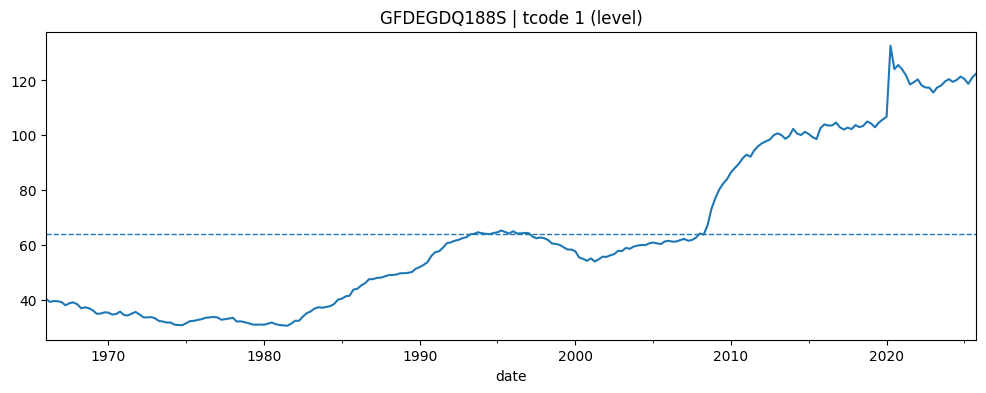

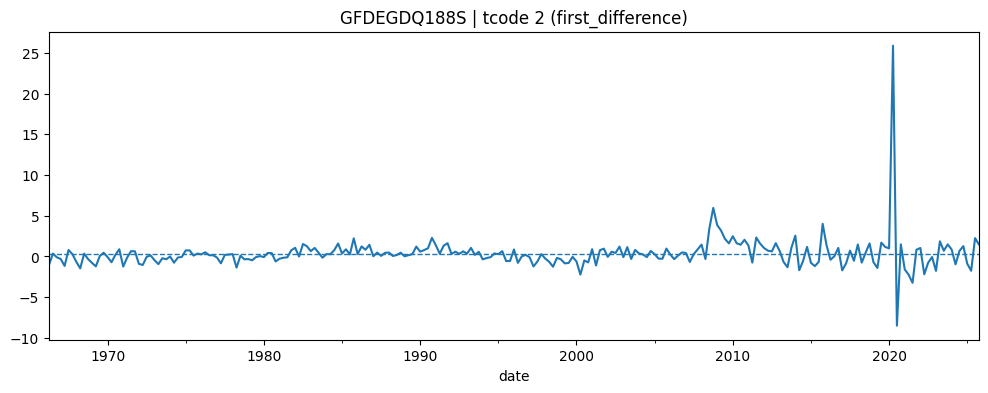

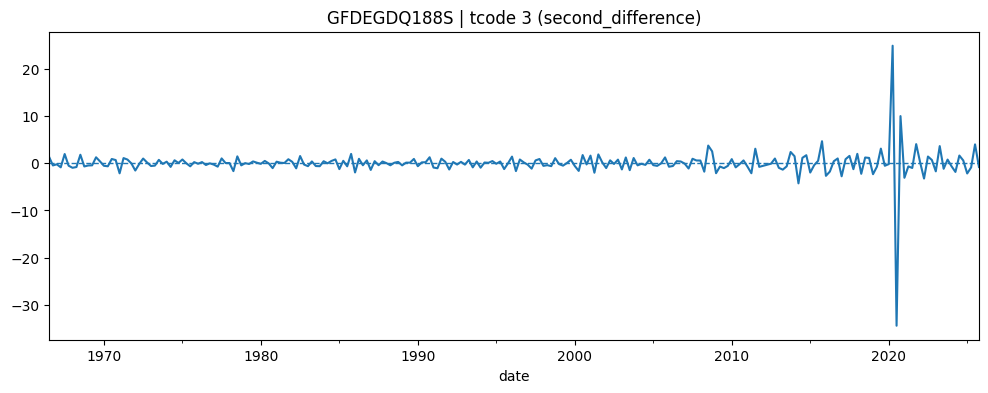

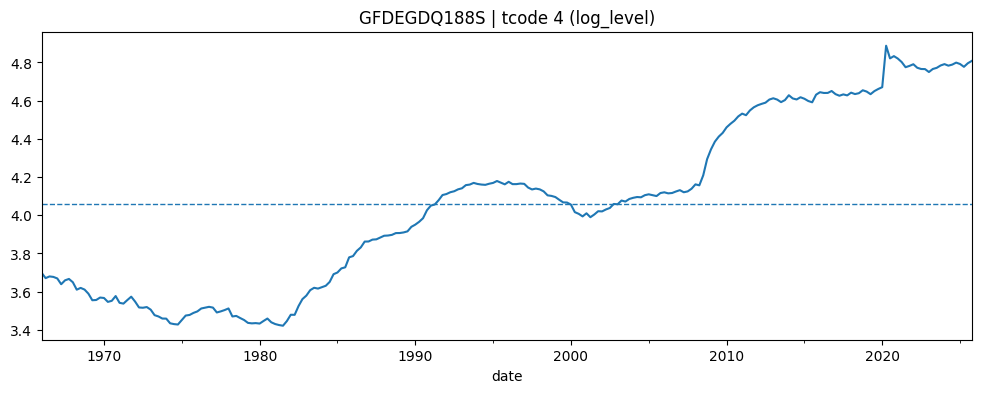

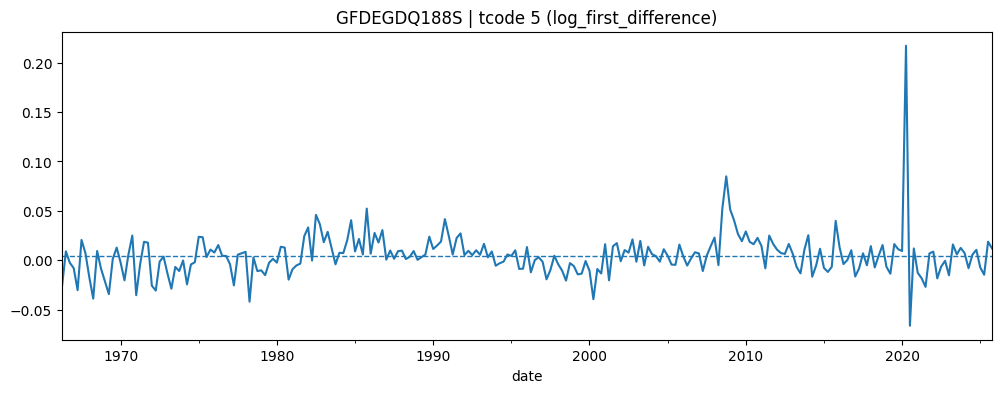

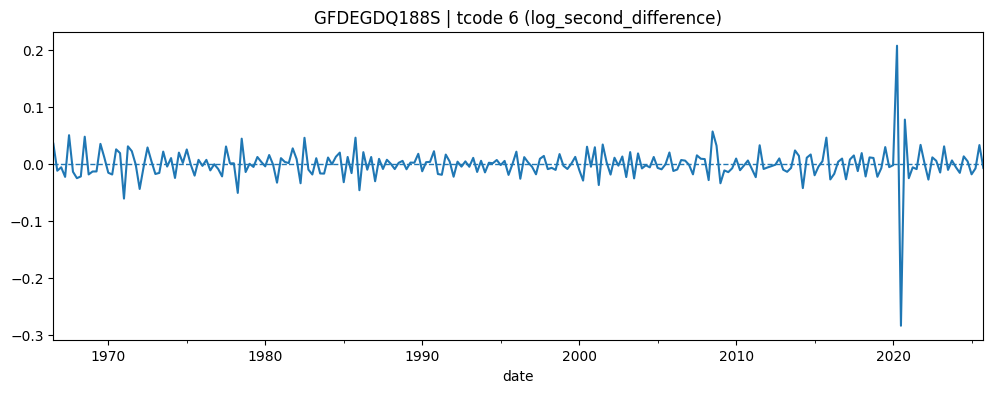

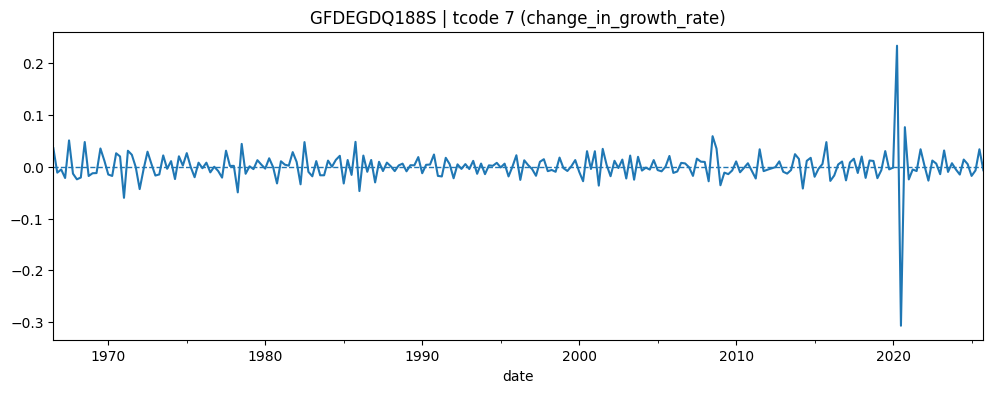

### Transformation Diagnostics

,label,n_obs,adf_pvalue,kpss_pvalue,arch_pvalue,stationarity_ok,variance_ok,autocorr_ok,overall_ok,recommended
tcode,,,,,,,,,,
1,level,240,9.960682e-01,0.010000,7.424775e-40,0,0,0,0,0
2,first_difference,239,1.898578e-11,0.072958,9.953523e-01,1,1,1,1,1
3,second_difference,238,3.050418e-15,0.100000,4.657140e-09,1,0,0,0,0
4,log_level,240,9.605013e-01,0.010000,4.449010e-41,0,0,0,0,0
5,log_first_difference,239,1.538755e-05,0.100000,9.967039e-01,1,1,0,1,0
6,log_second_difference,238,4.449519e-10,0.100000,7.365212e-09,1,0,0,0,0
7,change_in_growth_rate,238,3.019166e-10,0.100000,1.502795e-09,1,0,0,0,0


### Suggested TCode

,label,overall_ok,stationarity_ok,variance_ok,autocorr_ok
tcode,,,,,
2,first_difference,1,1,1,1


Updated markdown overview: Data\analyzed\debt.md


WindowsPath('C:/Users/olive/OneDrive/Dokumente/MASTER/MLFCS/MLFCS_RLMM_26/Data/analyzed/debt.md')

In [147]:
# =============================================================
# TEMPLATE COPY 3 - READY TO USE
# =============================================================

SERIES_ID = "GFDEGDQ188S"
CATEGORY = "debt"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
)
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
COMMENT = """
Federal Debt: Total Public Debt as Percent of Gross Domestic Product
- basically same series as above but in comparison to gdp, probly better
Caveats:
- none, tcode should be good
- maybe no homoscedastic
"""
TCODE1 = 2
TCODE2 = None
append_series_to_markdown_overview(
    series_id=SERIES_ID,
    category=CATEGORY,
    description=COMMENT,
    tcode1=TCODE1,
    tcode2=TCODE2,
    obs_df=obs,
    meta=meta,
    release=release,
    vintages=vintages,
)

### GFDEGDQ188S: Federal Debt: Total Public Debt as Percent of Gross Domestic Product

,value
period_covered,1966-01-01 -> 2025-10-01
frequency,Quarterly
seasonal_adjustment,Seasonally Adjusted
units,Percent of GDP
n_obs,240
n_missing,0
missing_share,0.0
missing_blocks,0
max_missing_block,0
n_vintage_dates,111


No missing intervals.

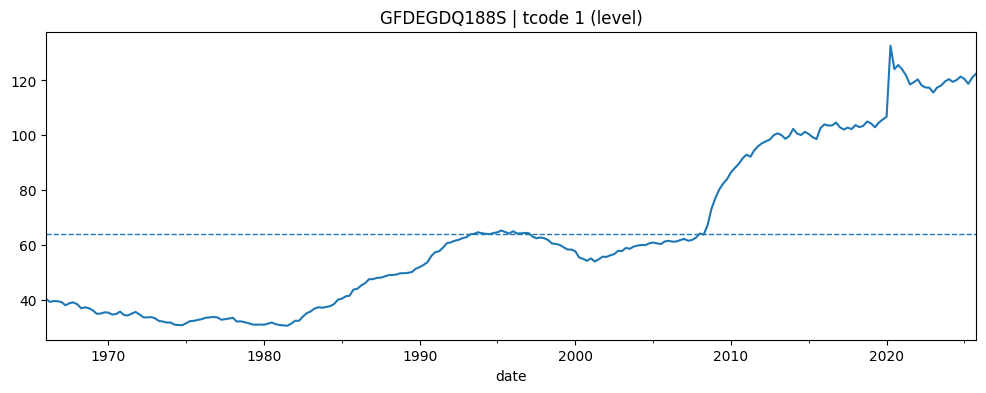

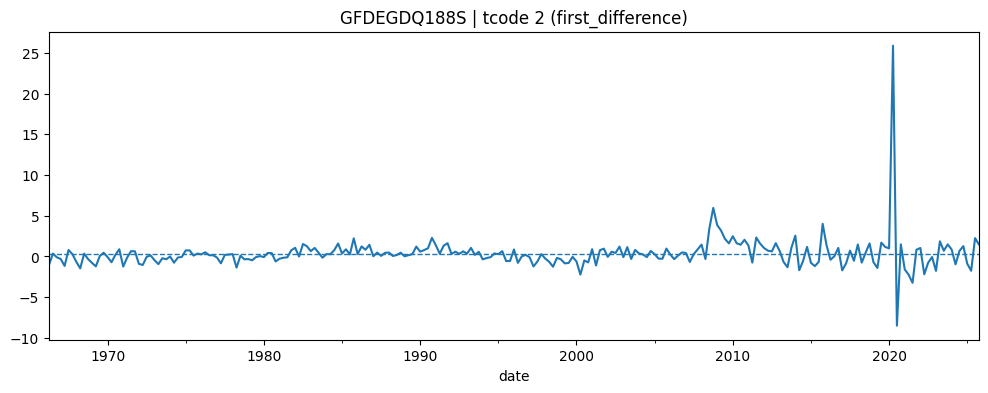

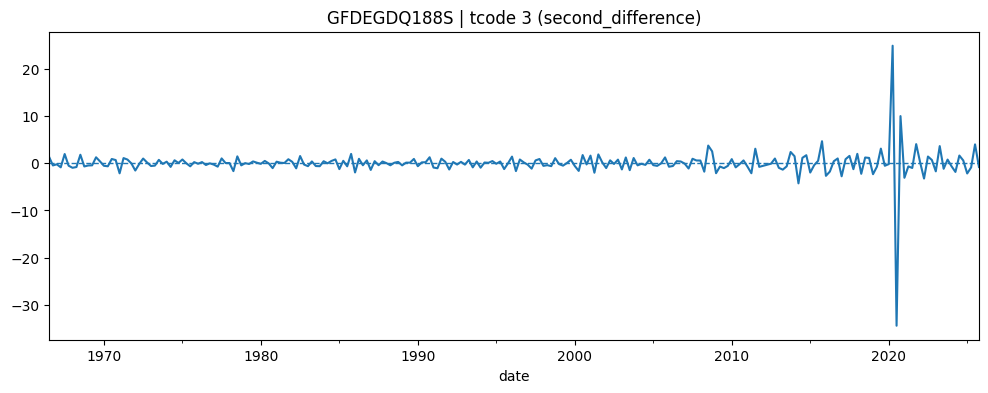

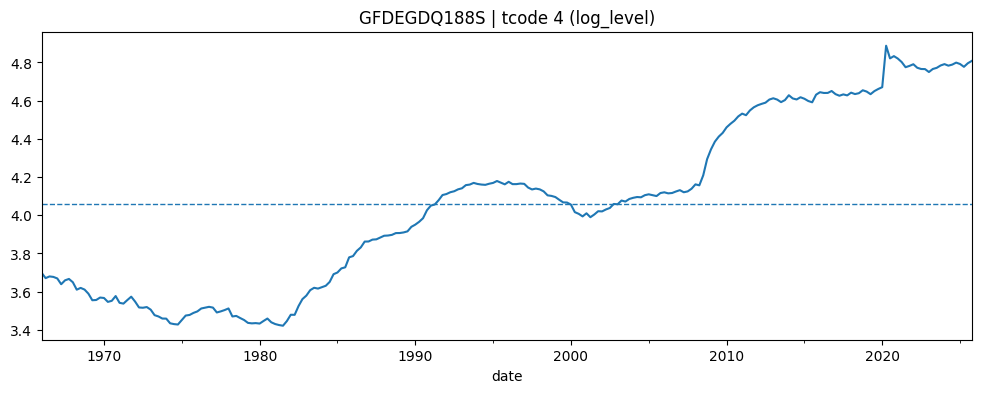

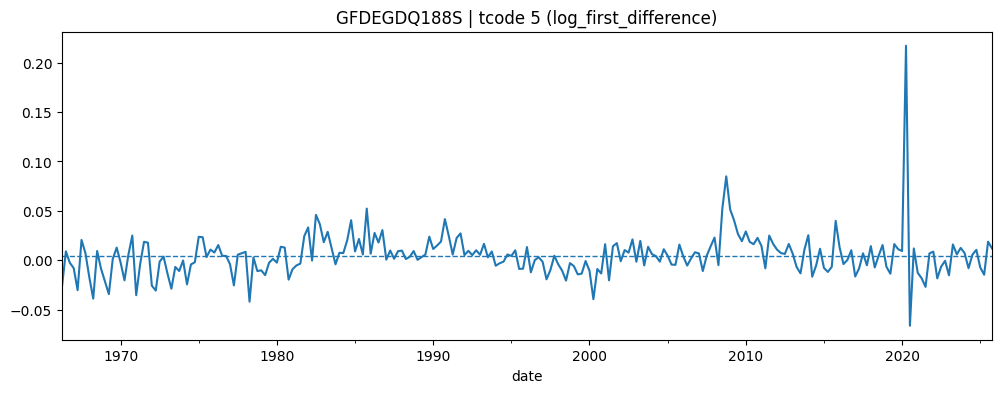

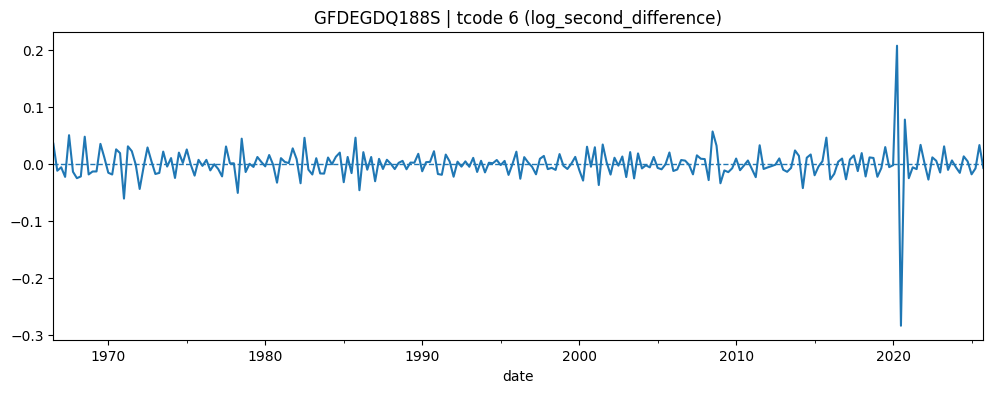

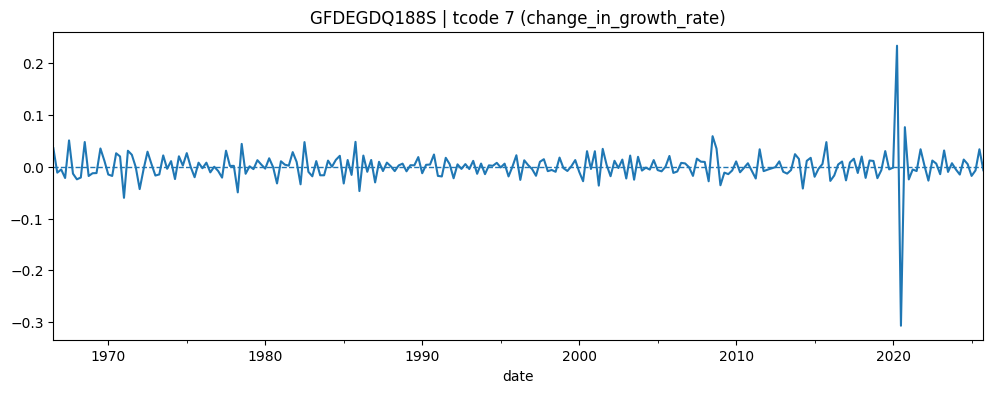

### Transformation Diagnostics

,label,n_obs,adf_pvalue,kpss_pvalue,arch_pvalue,stationarity_ok,variance_ok,autocorr_ok,overall_ok,recommended
tcode,,,,,,,,,,
1,level,240,9.960682e-01,0.010000,7.424775e-40,0,0,0,0,0
2,first_difference,239,1.898578e-11,0.072958,9.953523e-01,1,1,1,1,1
3,second_difference,238,3.050418e-15,0.100000,4.657140e-09,1,0,0,0,0
4,log_level,240,9.605013e-01,0.010000,4.449010e-41,0,0,0,0,0
5,log_first_difference,239,1.538755e-05,0.100000,9.967039e-01,1,1,0,1,0
6,log_second_difference,238,4.449519e-10,0.100000,7.365212e-09,1,0,0,0,0
7,change_in_growth_rate,238,3.019166e-10,0.100000,1.502795e-09,1,0,0,0,0


### Suggested TCode

,label,overall_ok,stationarity_ok,variance_ok,autocorr_ok
tcode,,,,,
2,first_difference,1,1,1,1


In [148]:
# =============================================================
# TEMPLATE COPY 3 - READY TO USE
# =============================================================

SERIES_ID = "GFDEGDQ188S"
CATEGORY = "debt"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
)
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
# COMMENT = """
# Why this series is relevant:
# - ...
# Caveats:
# - ...
# """
# TCODE1 = 1
# TCODE2 = None
# append_series_to_markdown_overview(
#     series_id=SERIES_ID,
#     category=CATEGORY,
#     description=COMMENT,
#     tcode1=TCODE1,
#     tcode2=TCODE2,
#     obs_df=obs,
#     meta=meta,
#     release=release,
#     vintages=vintages,
# )

### TCMDO: All Sectors; Debt Securities and Loans; Liability, Level

,value
period_covered,1945-10-01 -> 2025-07-01
frequency,"Quarterly, End of Period"
seasonal_adjustment,Not Seasonally Adjusted
units,Millions of U.S. Dollars
n_obs,320
n_missing,18
missing_share,0.0563
missing_blocks,6
max_missing_block,3
n_vintage_dates,54


Missing intervals: 6 blocks

,start,end,n_missing
0,1946-01-01,1946-07-01,3
1,1947-01-01,1947-07-01,3
2,1948-01-01,1948-07-01,3
3,1949-01-01,1949-07-01,3
4,1950-01-01,1950-07-01,3
5,1951-01-01,1951-07-01,3


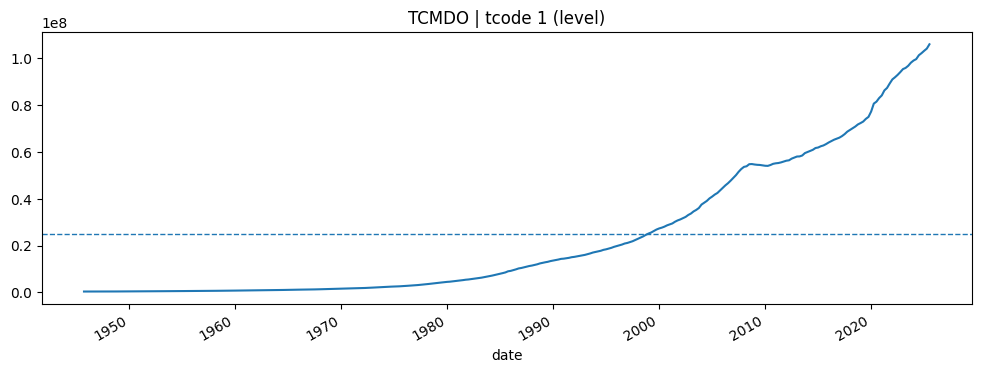

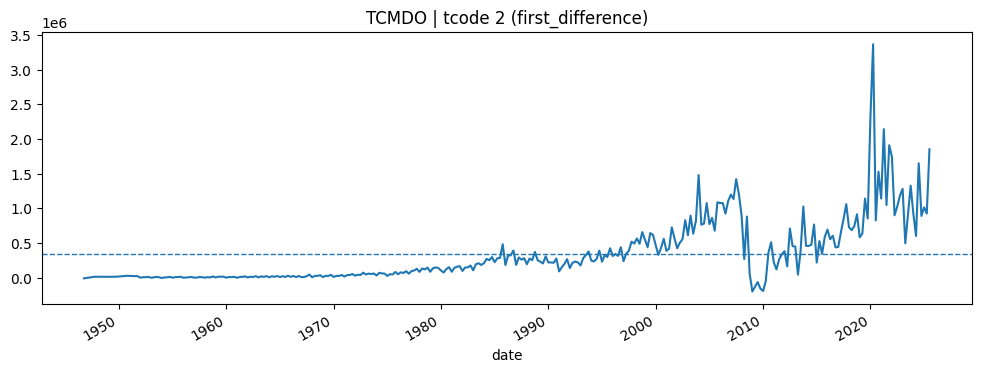

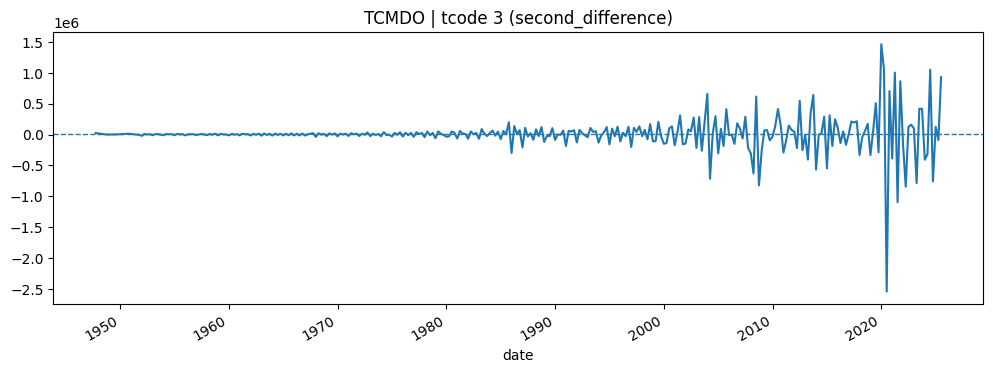

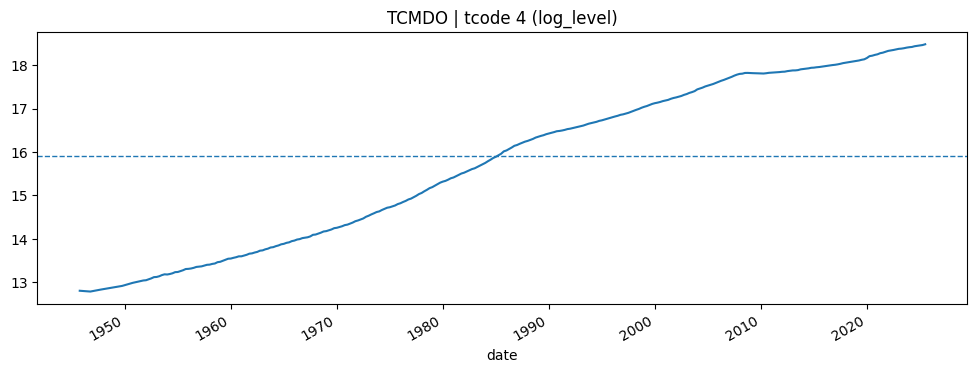

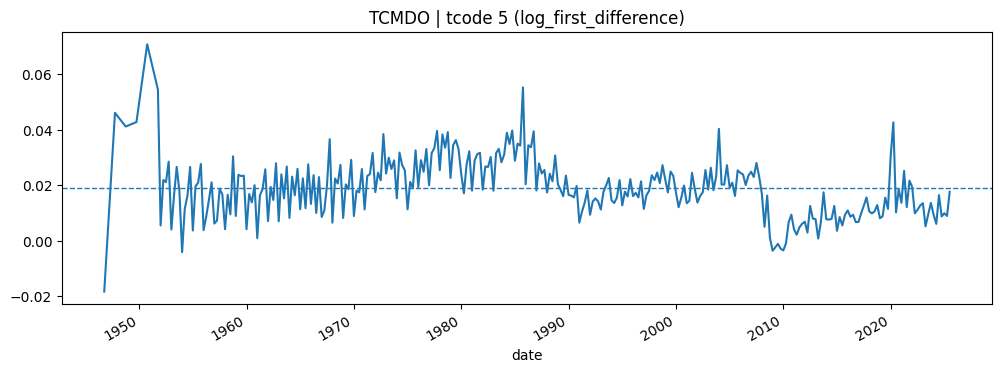

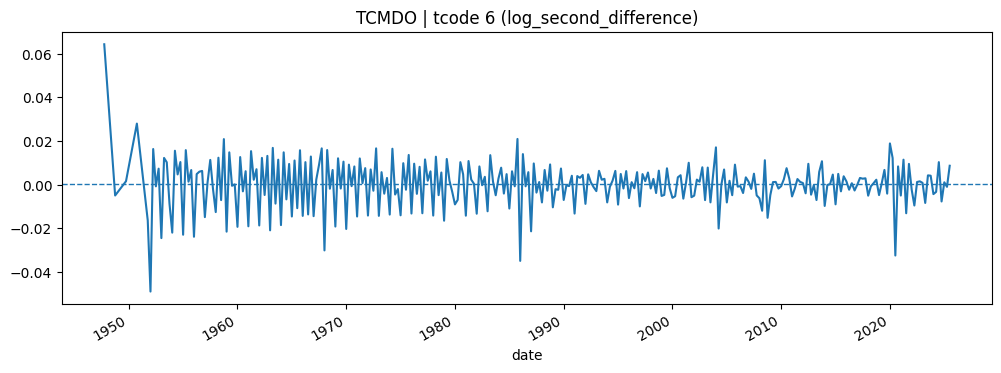

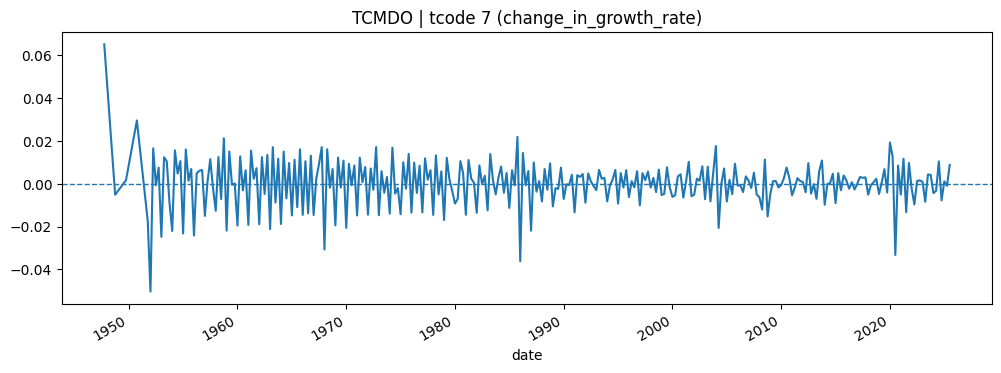

### Transformation Diagnostics

,label,n_obs,adf_pvalue,kpss_pvalue,arch_pvalue,stationarity_ok,variance_ok,autocorr_ok,overall_ok,recommended
tcode,,,,,,,,,,
1,level,302,1.000000e+00,0.010000,6.162028e-55,0,0,0,0,0
2,first_difference,301,5.366667e-01,0.010000,2.419873e-11,0,0,0,0,0
3,second_difference,300,9.237352e-10,0.091017,3.101738e-06,1,0,0,0,1
4,log_level,302,5.721512e-01,0.010000,5.960382e-55,0,0,0,0,0
5,log_first_difference,301,3.024081e-01,0.010000,6.952631e-14,0,0,0,0,0
6,log_second_difference,300,1.291236e-09,0.100000,4.224145e-13,1,0,0,0,0
7,change_in_growth_rate,300,1.252773e-09,0.100000,9.540367e-13,1,0,0,0,0


### Suggested TCode

,label,overall_ok,stationarity_ok,variance_ok,autocorr_ok
tcode,,,,,
3,second_difference,0,1,0,0


Updated markdown overview: Data\analyzed\debt.md


WindowsPath('C:/Users/olive/OneDrive/Dokumente/MASTER/MLFCS/MLFCS_RLMM_26/Data/analyzed/debt.md')

In [149]:
# =============================================================
# TEMPLATE COPY 3 - READY TO USE
# =============================================================

SERIES_ID = "TCMDO"
CATEGORY = "debt"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
)
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
COMMENT = """
All Sectors; Debt Securities and Loans; Liability, Level
- basically same as GFDEBTN but liability level not debt
Caveats:
- again tcode between 5 and 6, 5 with mean 0 would be good
- only yearly data in early series
"""
TCODE1 = 5
TCODE2 = 6
append_series_to_markdown_overview(
    series_id=SERIES_ID,
    category=CATEGORY,
    description=COMMENT,
    tcode1=TCODE1,
    tcode2=TCODE2,
    obs_df=obs,
    meta=meta,
    release=release,
    vintages=vintages,
)

### MVGFD027MNFRBDAL: Market Value of Gross Federal Debt

,value
period_covered,1942-01-01 -> 2026-02-01
frequency,Monthly
seasonal_adjustment,Not Seasonally Adjusted
units,Billions of Dollars
n_obs,1010
n_missing,0
missing_share,0.0
missing_blocks,0
max_missing_block,0
n_vintage_dates,118


No missing intervals.

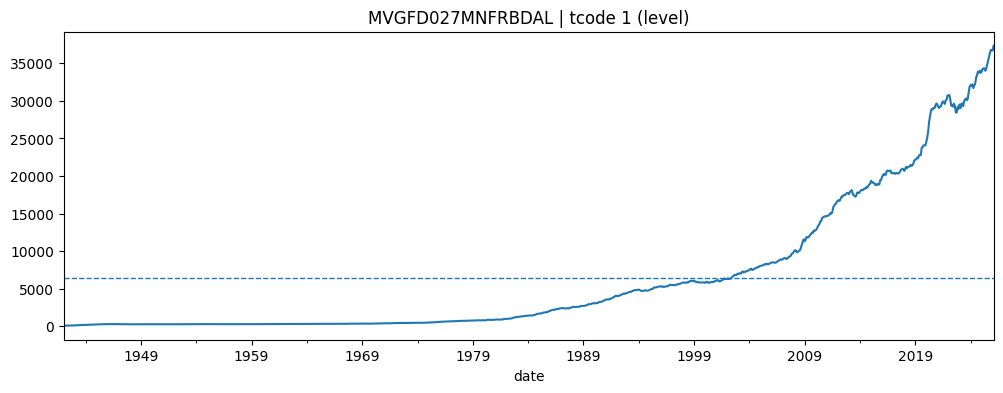

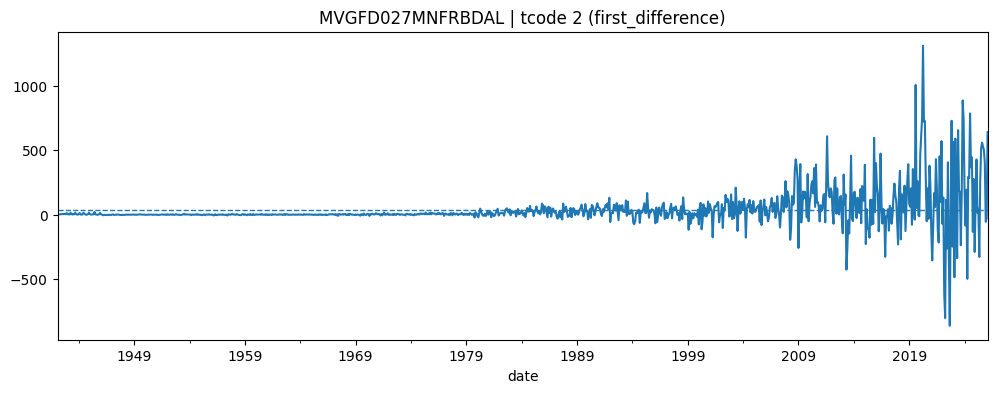

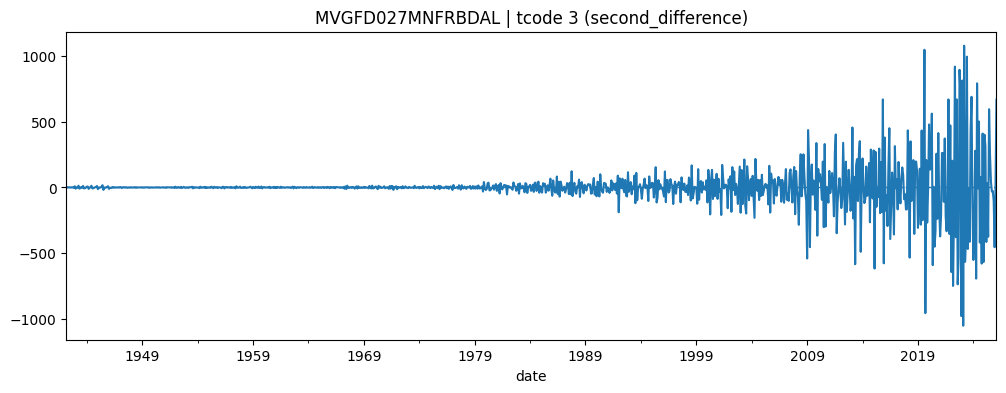

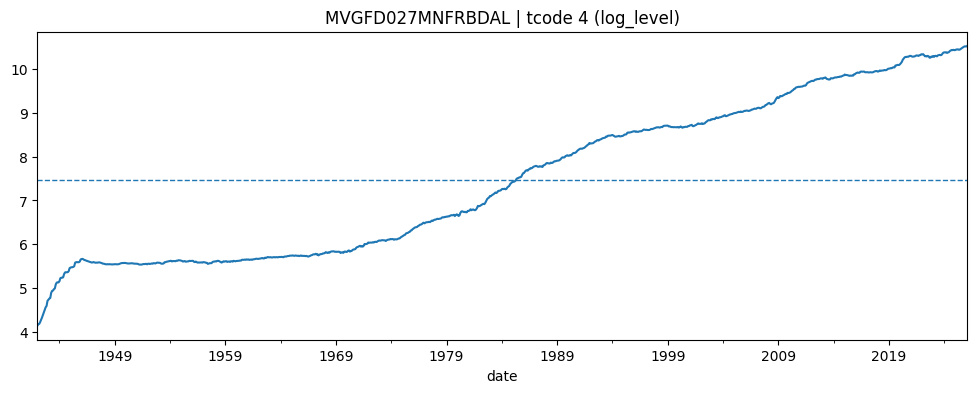

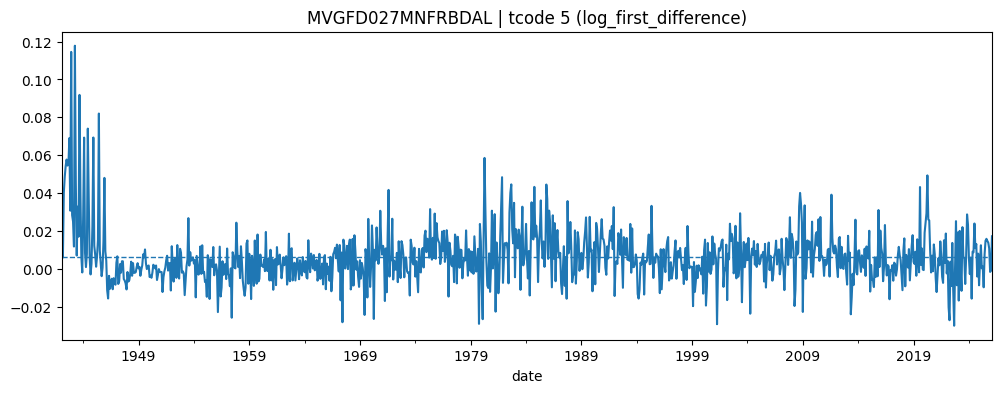

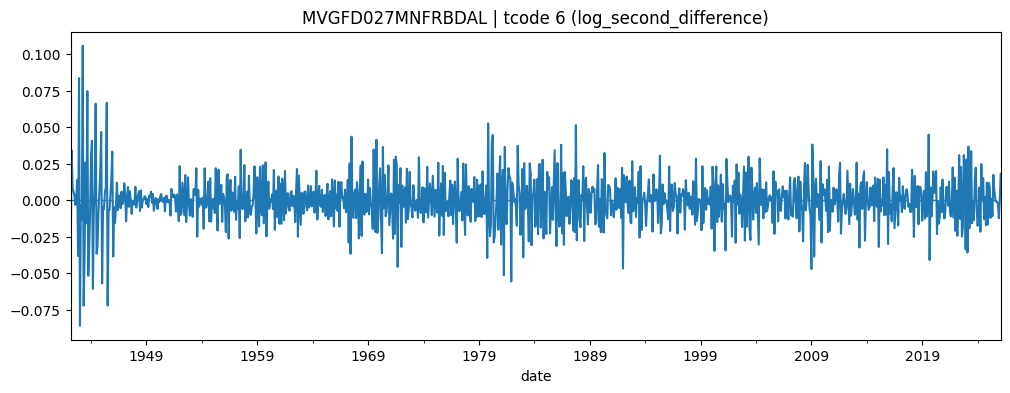

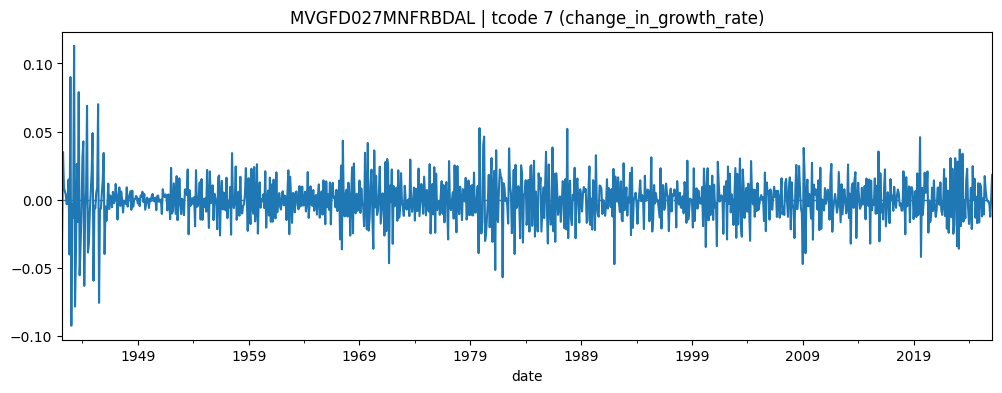

### Transformation Diagnostics

,label,n_obs,adf_pvalue,kpss_pvalue,arch_pvalue,stationarity_ok,variance_ok,autocorr_ok,overall_ok,recommended
tcode,,,,,,,,,,
1,level,1010,1.000000e+00,0.01,7.974228e-206,0,0,0,0,0
2,first_difference,1009,3.208518e-03,0.01,3.583105e-55,0,0,0,0,0
3,second_difference,1008,6.032514e-18,0.10,1.192760e-95,1,0,0,0,1
4,log_level,1010,9.938122e-01,0.01,6.107278e-206,0,0,0,0,0
5,log_first_difference,1009,4.970460e-09,0.10,6.631999e-77,1,0,0,0,0
6,log_second_difference,1008,1.204487e-26,0.10,2.123057e-61,1,0,0,0,0
7,change_in_growth_rate,1008,1.371809e-26,0.10,1.060103e-67,1,0,0,0,0


### Suggested TCode

,label,overall_ok,stationarity_ok,variance_ok,autocorr_ok
tcode,,,,,
3,second_difference,0,1,0,0


Updated markdown overview: Data\analyzed\debt.md


WindowsPath('C:/Users/olive/OneDrive/Dokumente/MASTER/MLFCS/MLFCS_RLMM_26/Data/analyzed/debt.md')

In [150]:
# =============================================================
# TEMPLATE COPY 3 - READY TO USE
# =============================================================

SERIES_ID = "MVGFD027MNFRBDAL"
CATEGORY = "debt"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
)
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
COMMENT = """
Market Value of Gross Federal Debt
- good because monthly
- same as GFDEBTN but market value, which is deemed more accurate
Caveats:
- again tcode 5 or 6, maybe t5 with mean 0
"""
TCODE1 = 5
TCODE2 = 6
append_series_to_markdown_overview(
    series_id=SERIES_ID,
    category=CATEGORY,
    description=COMMENT,
    tcode1=TCODE1,
    tcode2=TCODE2,
    obs_df=obs,
    meta=meta,
    release=release,
    vintages=vintages,
)

In [151]:
# =============================================================
# TEMPLATE COPY 3 - READY TO USE
# =============================================================

SERIES_ID = "FYPUGDA188S"
CATEGORY = "debt"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
)
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
COMMENT = """
Gross Federal Debt Held by the Public as Percent of Gross Domestic Product
- same as GFDEGDQ188S but anually therefore longer horizon
Caveats:
- not sure about tcode, test suggest 6 but I think 2 is enough?
"""
TCODE1 = 2
TCODE2 = None
append_series_to_markdown_overview(
    series_id=SERIES_ID,
    category=CATEGORY,
    description=COMMENT,
    tcode1=TCODE1,
    tcode2=TCODE2,
    obs_df=obs,
    meta=meta,
    release=release,
    vintages=vintages,
)

HTTPError: 500 Server Error: Internal Server Error for url: https://api.stlouisfed.org/fred/series?api_key=03b2991c82ff23f69c44889f53dac1d2&file_type=json&series_id=FYPUGDA188S

### NCBDBIQ027S: Nonfinancial Corporate Business; Debt Securities; Liability, Level

,value
period_covered,1945-10-01 -> 2025-07-01
frequency,"Quarterly, End of Period"
seasonal_adjustment,Not Seasonally Adjusted
units,Millions of U.S. Dollars
n_obs,320
n_missing,18
missing_share,0.0563
missing_blocks,6
max_missing_block,3
n_vintage_dates,51


Missing intervals: 6 blocks

,start,end,n_missing
0,1946-01-01,1946-07-01,3
1,1947-01-01,1947-07-01,3
2,1948-01-01,1948-07-01,3
3,1949-01-01,1949-07-01,3
4,1950-01-01,1950-07-01,3
5,1951-01-01,1951-07-01,3


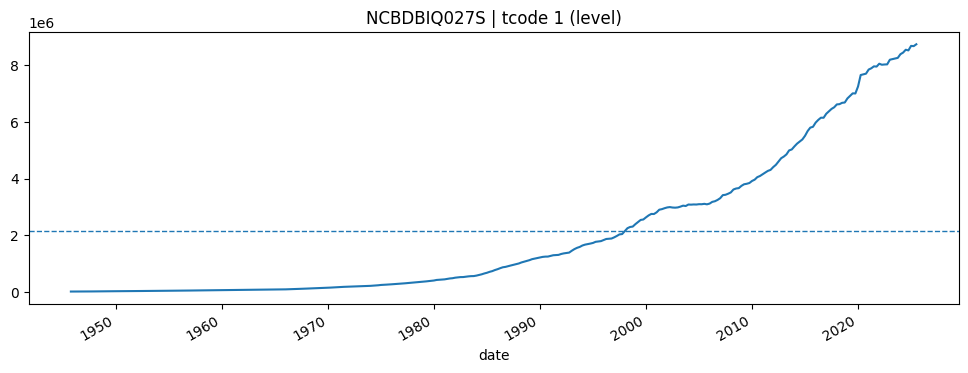

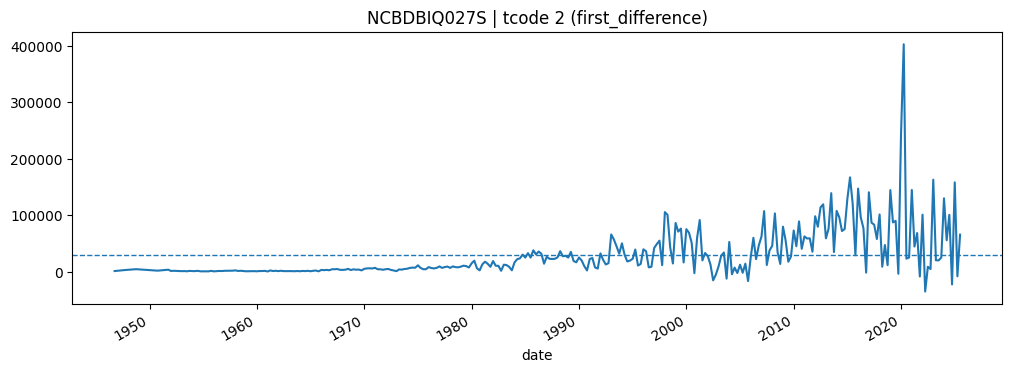

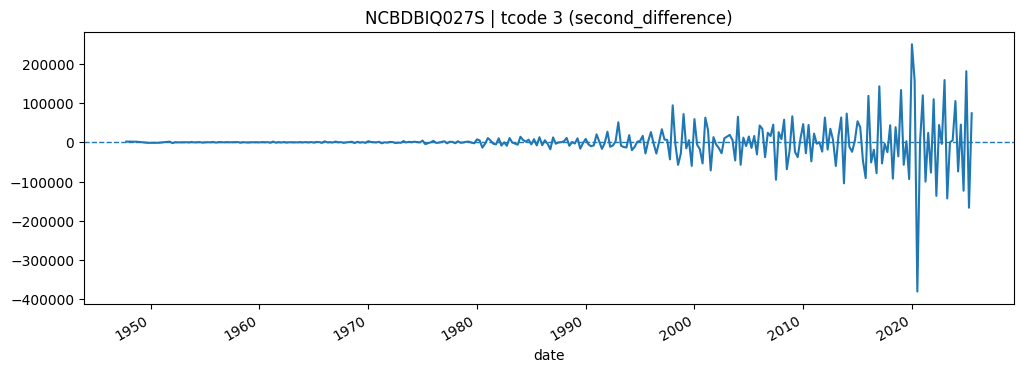

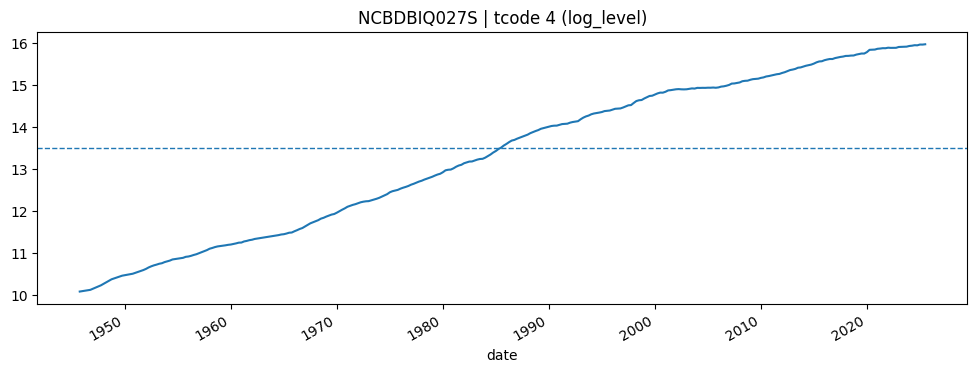

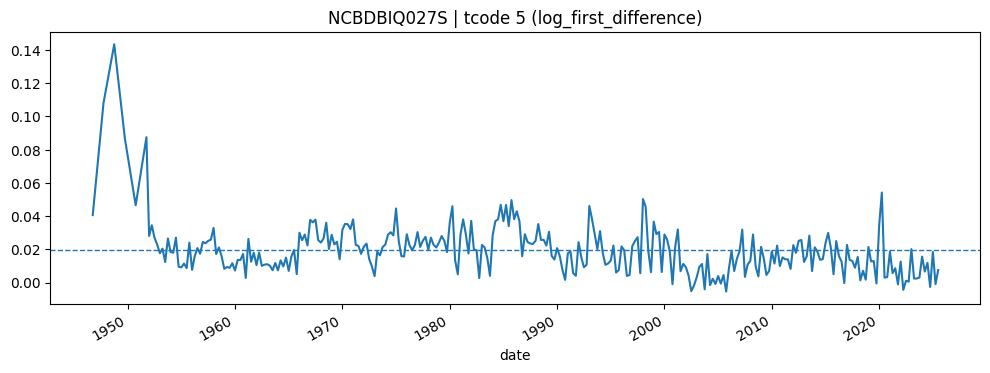

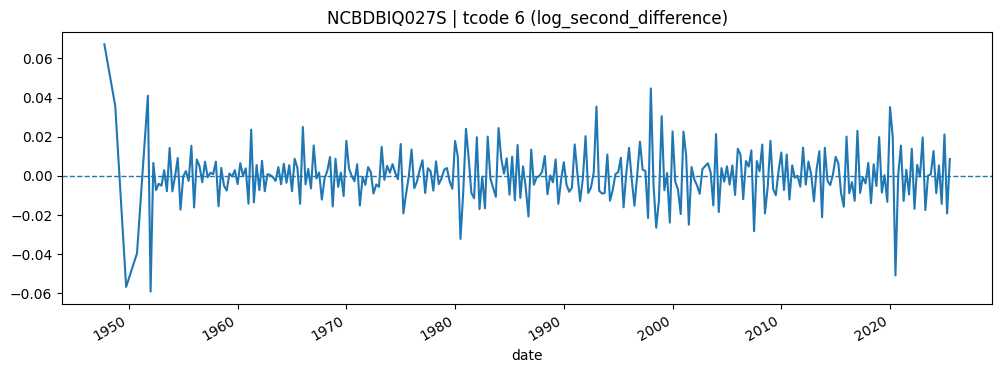

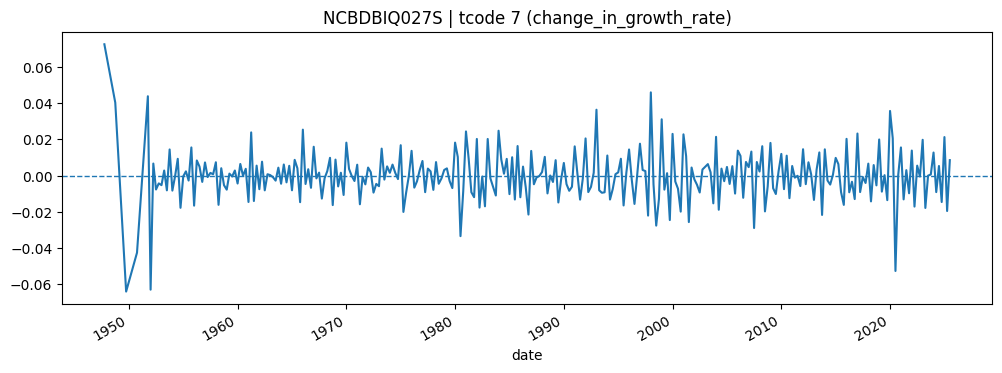

### Transformation Diagnostics

,label,n_obs,adf_pvalue,kpss_pvalue,arch_pvalue,stationarity_ok,variance_ok,autocorr_ok,overall_ok,recommended
tcode,,,,,,,,,,
1,level,302,9.975430e-01,0.01,6.757906e-55,0,0,0,0,0
2,first_difference,301,6.190006e-01,0.01,4.060794e-04,0,0,0,0,0
3,second_difference,300,9.227506e-11,0.10,3.140370e-08,1,0,0,0,0
4,log_level,302,4.940385e-01,0.01,6.037580e-55,0,0,0,0,0
5,log_first_difference,301,9.649705e-03,0.01,9.117021e-07,0,0,0,0,0
6,log_second_difference,300,6.353595e-13,0.10,7.006975e-02,1,1,0,1,1
7,change_in_growth_rate,300,6.461223e-13,0.10,7.458134e-02,1,1,0,1,0


### Suggested TCode

,label,overall_ok,stationarity_ok,variance_ok,autocorr_ok
tcode,,,,,
6,log_second_difference,1,1,1,0


Updated markdown overview: Data\analyzed\debt-persector.md


WindowsPath('C:/Users/olive/OneDrive/Dokumente/MASTER/MLFCS/MLFCS_RLMM_26/Data/analyzed/debt-persector.md')

In [ ]:
# =============================================================
# TEMPLATE EMPTY - READY TO USE
# =============================================================

SERIES_ID = "NCBDBIQ027S"
CATEGORY = "debt-persector"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
 )
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
COMMENT = """
Nonfinancial Corporate Business; Debt Securities; Liability, Level
- per sector of TCMDO
Caveats:
- t5 or t6 again
- same tcode for all per sector
"""
TCODE1 = 5
TCODE2 = 6
append_series_to_markdown_overview(
    series_id=SERIES_ID,
    category=CATEGORY,
    description=COMMENT,
    tcode1=TCODE1,
    tcode2=TCODE2,
    obs_df=obs,
    meta=meta,
    release=release,
    vintages=vintages,
)

### SLGSDODNS: State and Local Governments; Debt Securities and Loans; Liability, Level

,value
period_covered,1945-10-01 -> 2025-07-01
frequency,"Quarterly, End of Period"
seasonal_adjustment,Seasonally Adjusted Annual Rate
units,Millions of U.S. Dollars
n_obs,320
n_missing,18
missing_share,0.0563
missing_blocks,6
max_missing_block,3
n_vintage_dates,63


Missing intervals: 6 blocks

,start,end,n_missing
0,1946-01-01,1946-07-01,3
1,1947-01-01,1947-07-01,3
2,1948-01-01,1948-07-01,3
3,1949-01-01,1949-07-01,3
4,1950-01-01,1950-07-01,3
5,1951-01-01,1951-07-01,3


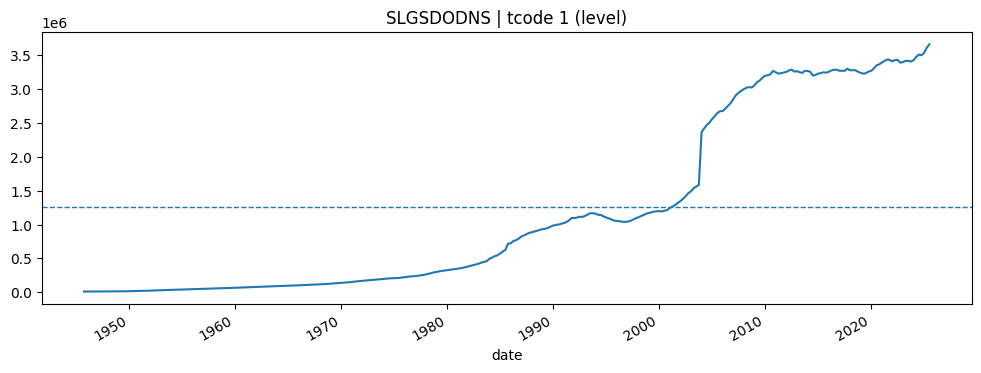

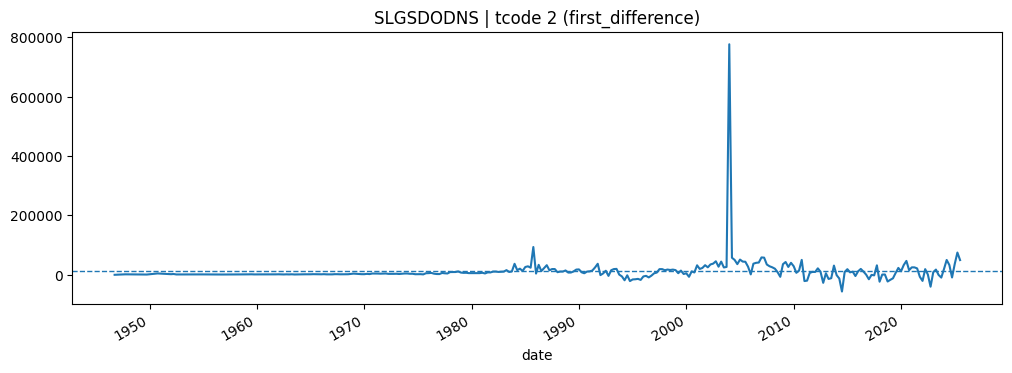

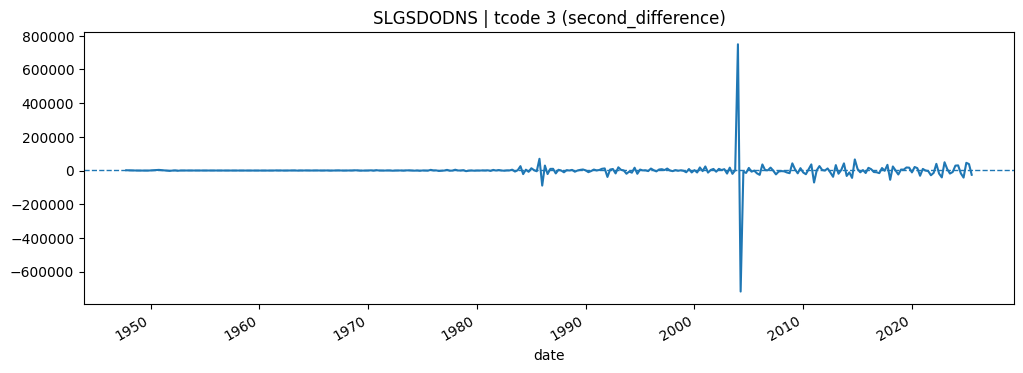

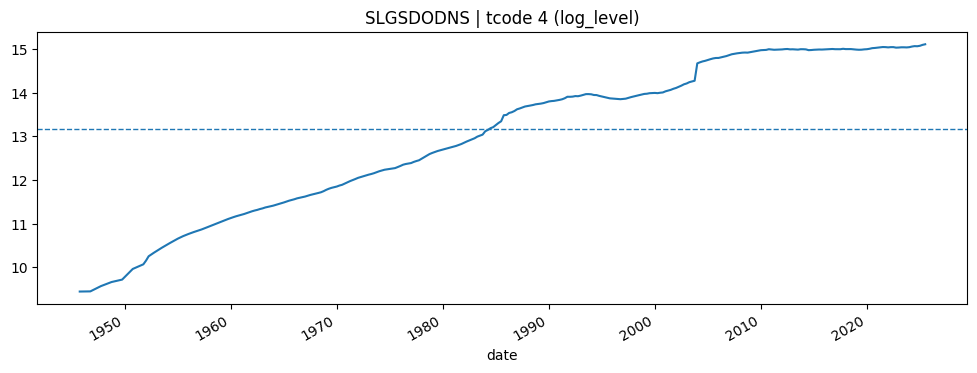

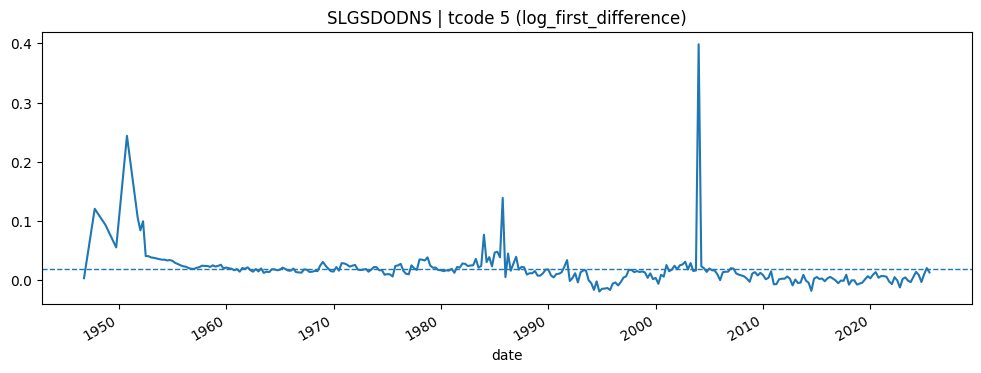

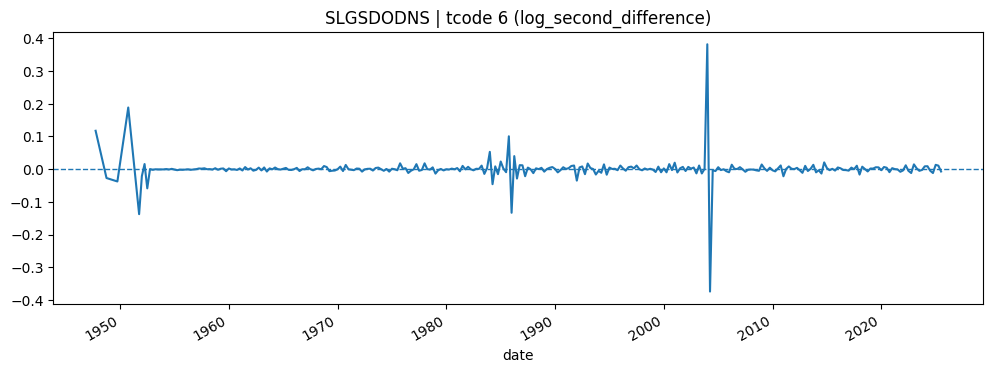

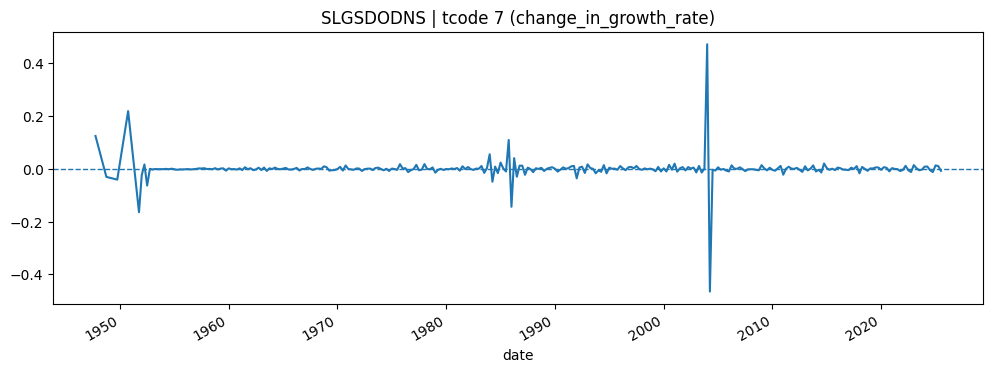

### Transformation Diagnostics

,label,n_obs,adf_pvalue,kpss_pvalue,arch_pvalue,stationarity_ok,variance_ok,autocorr_ok,overall_ok,recommended
tcode,,,,,,,,,,
1,level,302,9.944520e-01,0.010000,8.542148e-55,0,0,0,0,0
2,first_difference,301,8.738403e-09,0.042195,1.000000e+00,0,1,0,0,0
3,second_difference,300,1.248139e-13,0.082453,1.502384e-21,1,0,0,0,1
4,log_level,302,2.150624e-01,0.010000,7.114600e-55,0,0,0,0,0
5,log_first_difference,301,3.341519e-08,0.010000,1.000000e+00,0,1,0,0,0
6,log_second_difference,300,2.380873e-20,0.100000,7.777218e-22,1,0,0,0,0
7,change_in_growth_rate,300,1.043349e-20,0.100000,4.595691e-22,1,0,0,0,0


### Suggested TCode

,label,overall_ok,stationarity_ok,variance_ok,autocorr_ok
tcode,,,,,
3,second_difference,0,1,0,0


Updated markdown overview: Data\analyzed\debt-persector.md


WindowsPath('C:/Users/olive/OneDrive/Dokumente/MASTER/MLFCS/MLFCS_RLMM_26/Data/analyzed/debt-persector.md')

In [ ]:
# =============================================================
# TEMPLATE EMPTY - READY TO USE
# =============================================================

SERIES_ID = "SLGSDODNS"
CATEGORY = "debt-persector"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
 )
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
COMMENT = """
State and Local Governments; Debt Securities and Loans; Liability, Level
- per sector of TCMDO
Caveats:
- t5 or t6 again (t5 with mean 0?)
- same tcode for all per sector
"""
TCODE1 = 5
TCODE2 = 6
append_series_to_markdown_overview(
    series_id=SERIES_ID,
    category=CATEGORY,
    description=COMMENT,
    tcode1=TCODE1,
    tcode2=TCODE2,
    obs_df=obs,
    meta=meta,
    release=release,
    vintages=vintages,
)

### FGSDODNS: Federal Government; Debt Securities and Loans; Liability, Level

,value
period_covered,1945-10-01 -> 2025-07-01
frequency,"Quarterly, End of Period"
seasonal_adjustment,Seasonally Adjusted Annual Rate
units,Millions of U.S. Dollars
n_obs,320
n_missing,18
missing_share,0.0563
missing_blocks,6
max_missing_block,3
n_vintage_dates,63


Missing intervals: 6 blocks

,start,end,n_missing
0,1946-01-01,1946-07-01,3
1,1947-01-01,1947-07-01,3
2,1948-01-01,1948-07-01,3
3,1949-01-01,1949-07-01,3
4,1950-01-01,1950-07-01,3
5,1951-01-01,1951-07-01,3


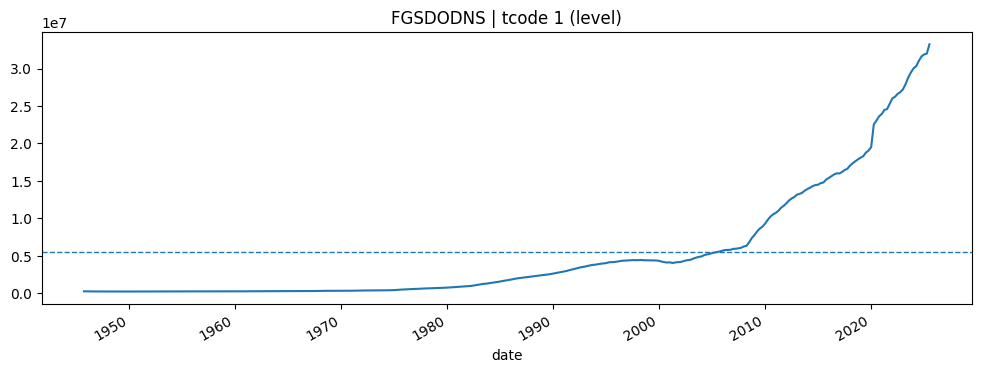

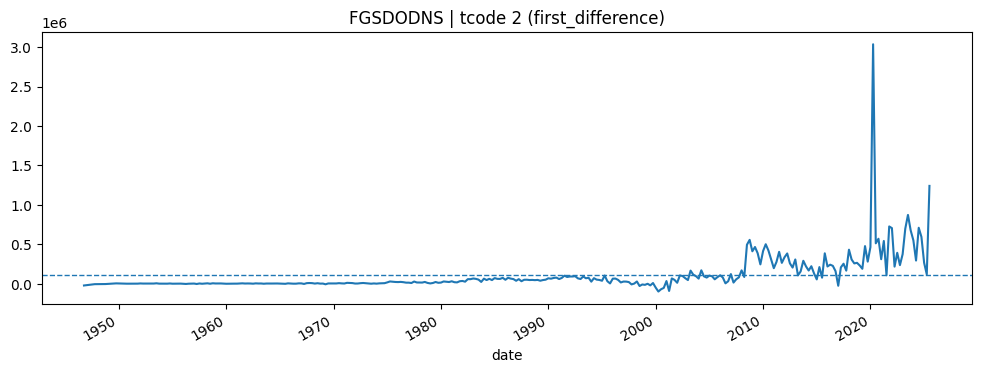

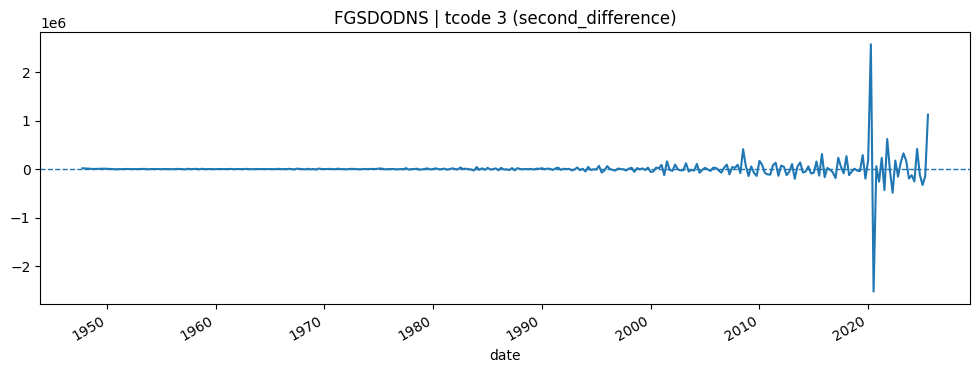

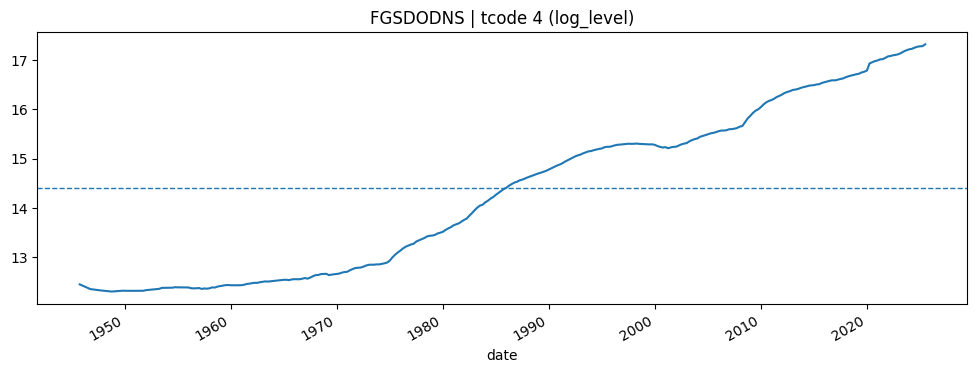

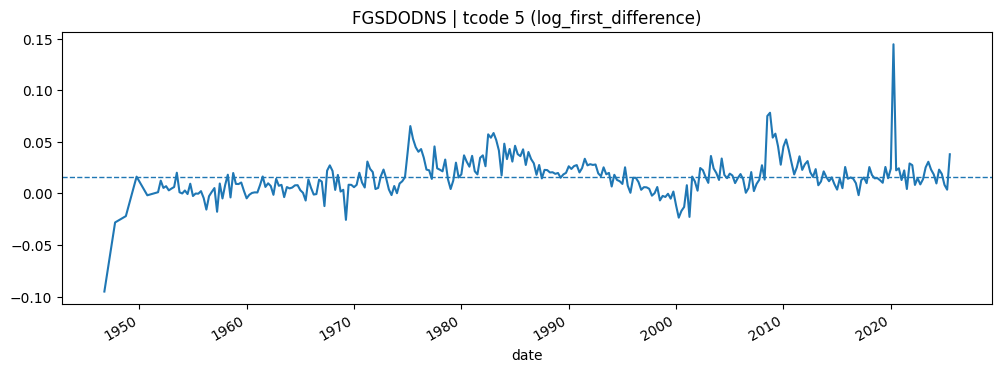

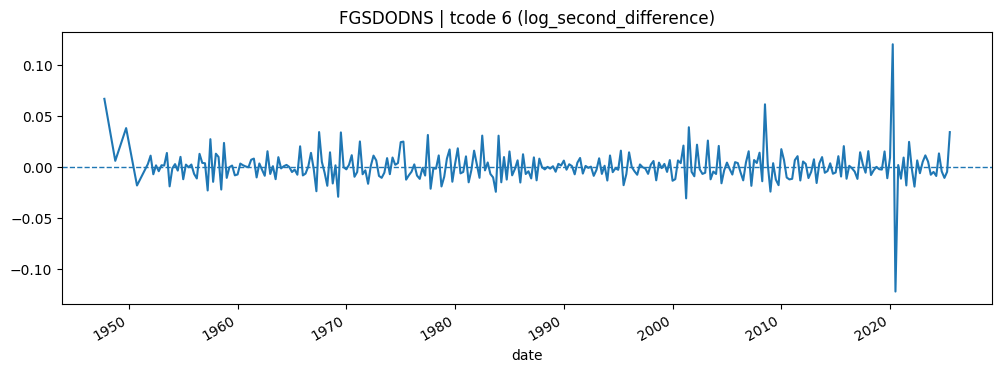

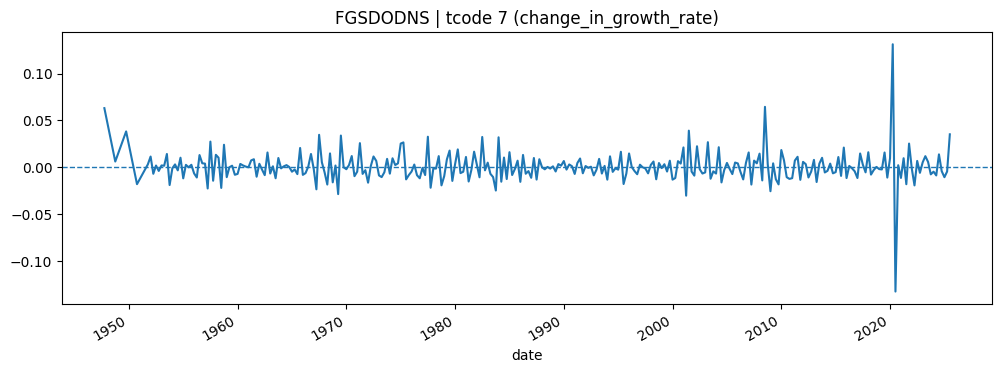

### Transformation Diagnostics

,label,n_obs,adf_pvalue,kpss_pvalue,arch_pvalue,stationarity_ok,variance_ok,autocorr_ok,overall_ok,recommended
tcode,,,,,,,,,,
1,level,302,1.000000e+00,0.010000,7.800209e-55,0,0,0,0,0
2,first_difference,301,9.378675e-01,0.010000,9.990193e-01,0,1,0,0,0
3,second_difference,300,5.529148e-09,0.100000,6.789857e-23,1,0,0,0,1
4,log_level,302,9.906733e-01,0.010000,6.385578e-55,0,0,0,0,0
5,log_first_difference,301,1.755512e-03,0.016739,9.936581e-01,0,1,0,0,0
6,log_second_difference,300,3.765168e-18,0.100000,5.593748e-16,1,0,0,0,0
7,change_in_growth_rate,300,3.160945e-18,0.100000,1.262405e-16,1,0,0,0,0


### Suggested TCode

,label,overall_ok,stationarity_ok,variance_ok,autocorr_ok
tcode,,,,,
3,second_difference,0,1,0,0


Updated markdown overview: Data\analyzed\debt-persector.md


WindowsPath('C:/Users/olive/OneDrive/Dokumente/MASTER/MLFCS/MLFCS_RLMM_26/Data/analyzed/debt-persector.md')

In [ ]:
# =============================================================
# TEMPLATE EMPTY - READY TO USE
# =============================================================

SERIES_ID = "FGSDODNS"
CATEGORY = "debt-persector"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
 )
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
COMMENT = """
Federal Government; Debt Securities and Loans; Liability, Level
- per sector of TCMDO
Caveats:
- t5 or t6 again, t5 with mean, big peak though
- same tcode for all per sector
"""
TCODE1 = 5
TCODE2 = 6
append_series_to_markdown_overview(
    series_id=SERIES_ID,
    category=CATEGORY,
    description=COMMENT,
    tcode1=TCODE1,
    tcode2=TCODE2,
    obs_df=obs,
    meta=meta,
    release=release,
    vintages=vintages,
)

### SBDDSA: Security Brokers and Dealers; Debt Securities; Asset, Level

,value
period_covered,1945-10-01 -> 2025-07-01
frequency,"Quarterly, End of Period"
seasonal_adjustment,Not Seasonally Adjusted
units,Millions of U.S. Dollars
n_obs,320
n_missing,18
missing_share,0.0563
missing_blocks,6
max_missing_block,3
n_vintage_dates,42


Missing intervals: 6 blocks

,start,end,n_missing
0,1946-01-01,1946-07-01,3
1,1947-01-01,1947-07-01,3
2,1948-01-01,1948-07-01,3
3,1949-01-01,1949-07-01,3
4,1950-01-01,1950-07-01,3
5,1951-01-01,1951-07-01,3


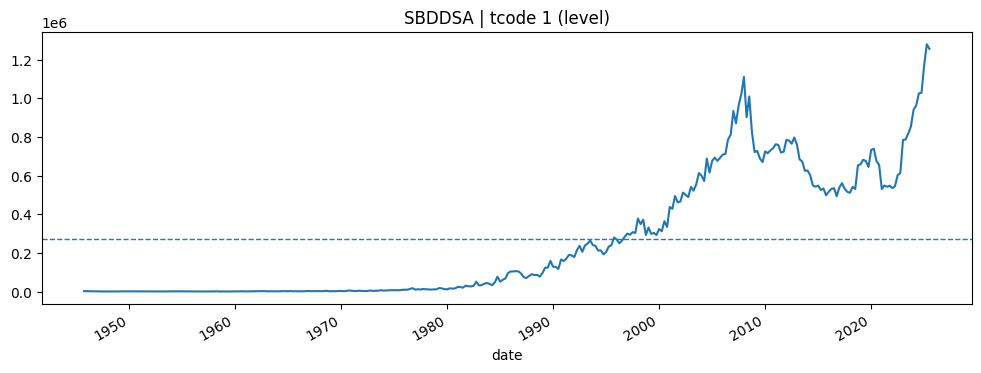

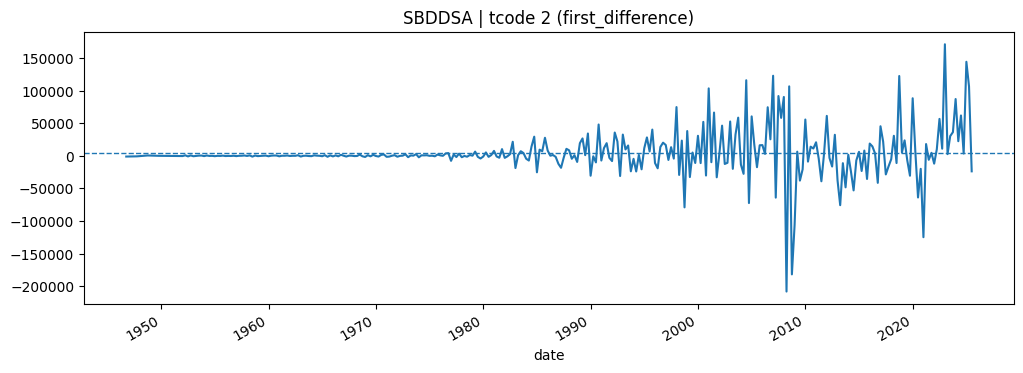

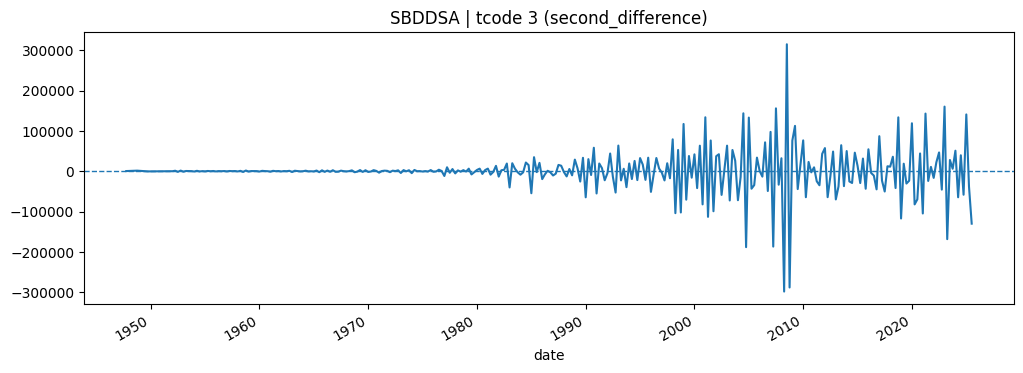

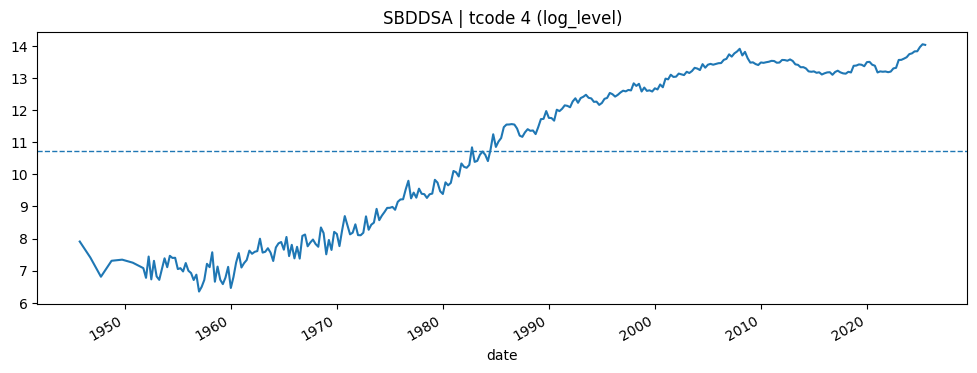

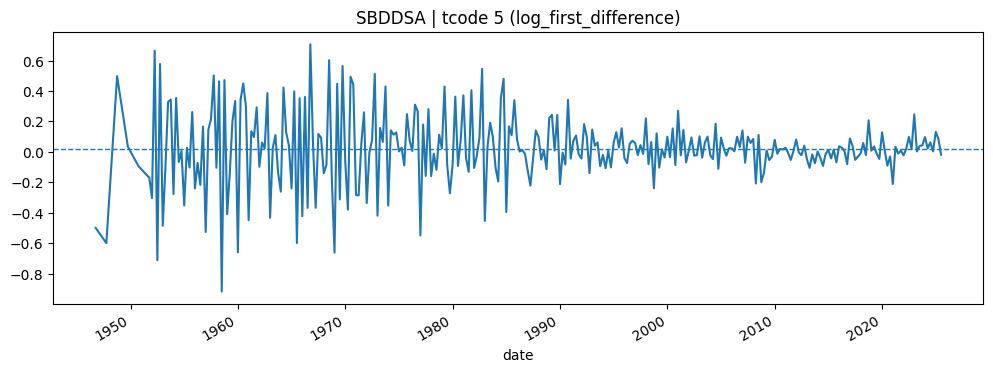

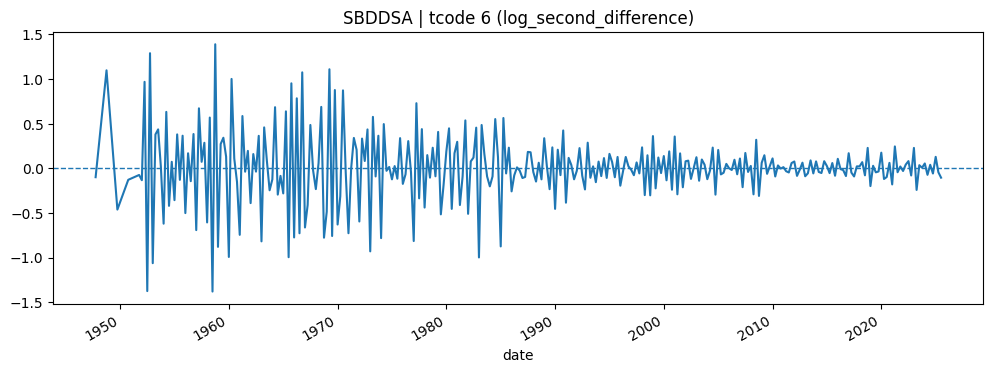

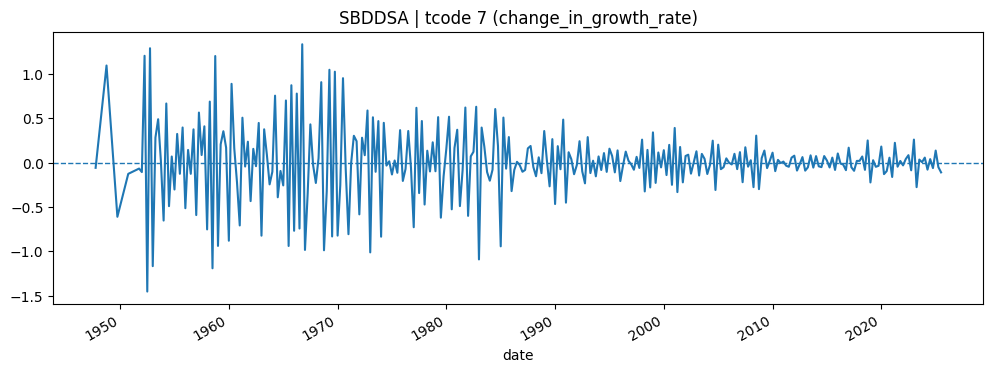

### Transformation Diagnostics

,label,n_obs,adf_pvalue,kpss_pvalue,arch_pvalue,stationarity_ok,variance_ok,autocorr_ok,overall_ok,recommended
tcode,,,,,,,,,,
1,level,302,9.917705e-01,0.010000,1.625644e-50,0,0,0,0,0
2,first_difference,301,1.608249e-01,0.100000,1.111958e-10,0,0,0,0,0
3,second_difference,300,8.700473e-11,0.100000,5.223142e-27,1,0,0,0,1
4,log_level,302,8.351776e-01,0.010000,1.972460e-51,0,0,0,0,0
5,log_first_difference,301,3.525093e-03,0.041667,3.025498e-08,0,0,0,0,0
6,log_second_difference,300,1.147783e-15,0.100000,8.979066e-17,1,0,0,0,0
7,change_in_growth_rate,300,6.391096e-14,0.100000,1.919190e-16,1,0,0,0,0


### Suggested TCode

,label,overall_ok,stationarity_ok,variance_ok,autocorr_ok
tcode,,,,,
3,second_difference,0,1,0,0


Updated markdown overview: Data\analyzed\debt-persector.md


WindowsPath('C:/Users/olive/OneDrive/Dokumente/MASTER/MLFCS/MLFCS_RLMM_26/Data/analyzed/debt-persector.md')

In [ ]:
# =============================================================
# TEMPLATE EMPTY - READY TO USE
# =============================================================

SERIES_ID = "SBDDSA"
CATEGORY = "debt-persector"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
 )
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
COMMENT = """
Security Brokers and Dealers; Debt Securities; Asset, Level
- per sector of TCMDO
Caveats:
- t5 or t6 again
- I THINK ONE CAN SEE REGULATION OF SECURITY BROKES AS HOW MUCH DEBT THEY CAN OWN
- same tcode for all per sector
"""
TCODE1 = 5
TCODE2 = 6
append_series_to_markdown_overview(
    series_id=SERIES_ID,
    category=CATEGORY,
    description=COMMENT,
    tcode1=TCODE1,
    tcode2=TCODE2,
    obs_df=obs,
    meta=meta,
    release=release,
    vintages=vintages,
)

### TBSDODNS: Nonfinancial Business; Debt Securities and Loans; Liability, Level

,value
period_covered,1945-10-01 -> 2025-07-01
frequency,"Quarterly, End of Period"
seasonal_adjustment,Seasonally Adjusted Annual Rate
units,Millions of U.S. Dollars
n_obs,320
n_missing,18
missing_share,0.0563
missing_blocks,6
max_missing_block,3
n_vintage_dates,63


Missing intervals: 6 blocks

,start,end,n_missing
0,1946-01-01,1946-07-01,3
1,1947-01-01,1947-07-01,3
2,1948-01-01,1948-07-01,3
3,1949-01-01,1949-07-01,3
4,1950-01-01,1950-07-01,3
5,1951-01-01,1951-07-01,3


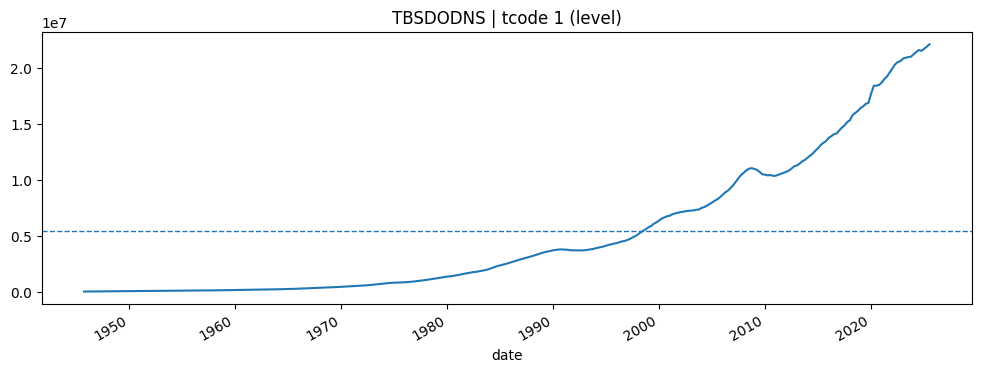

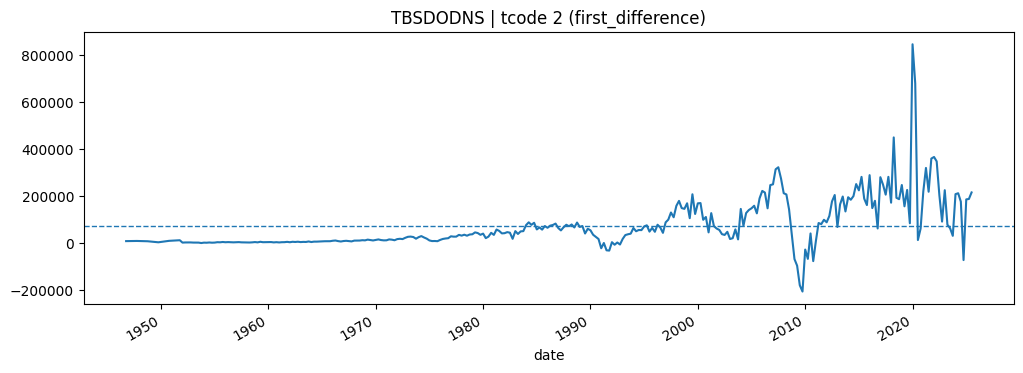

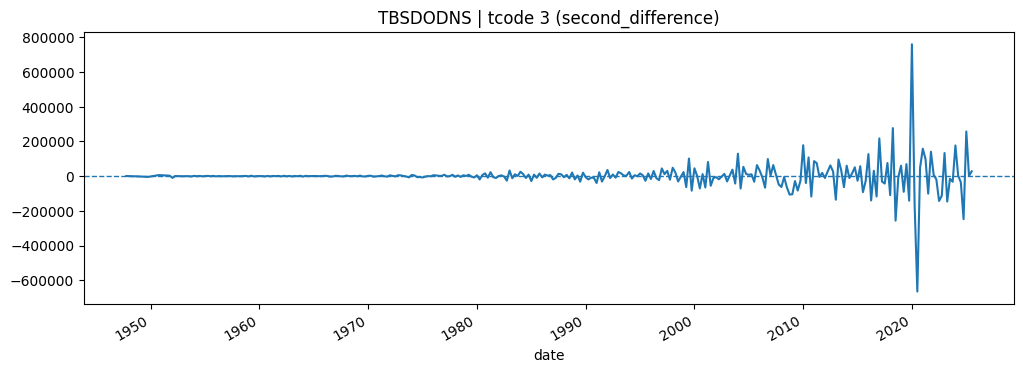

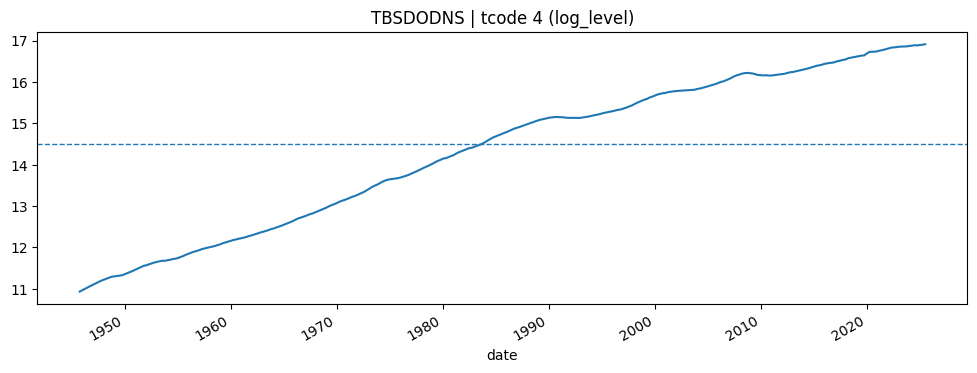

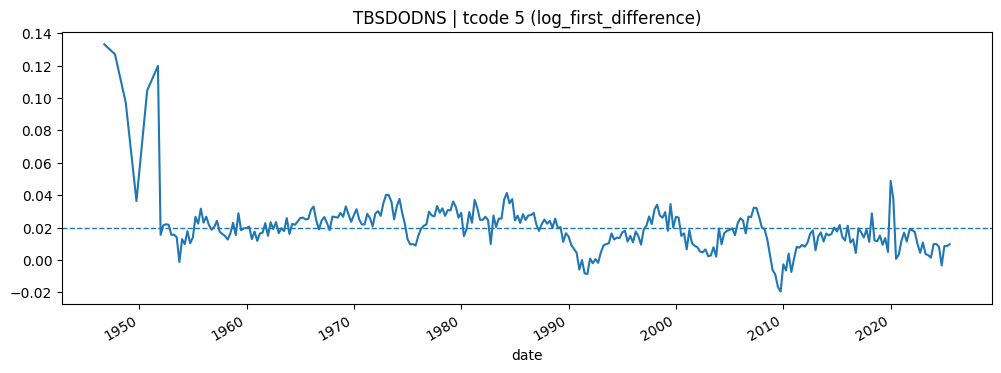

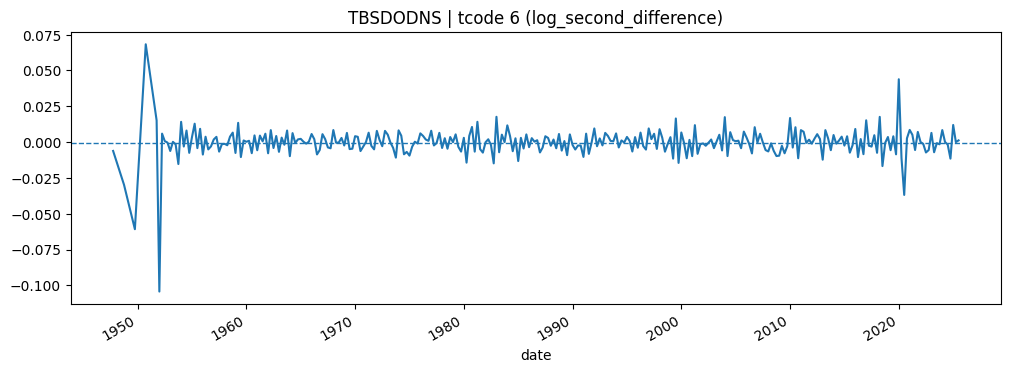

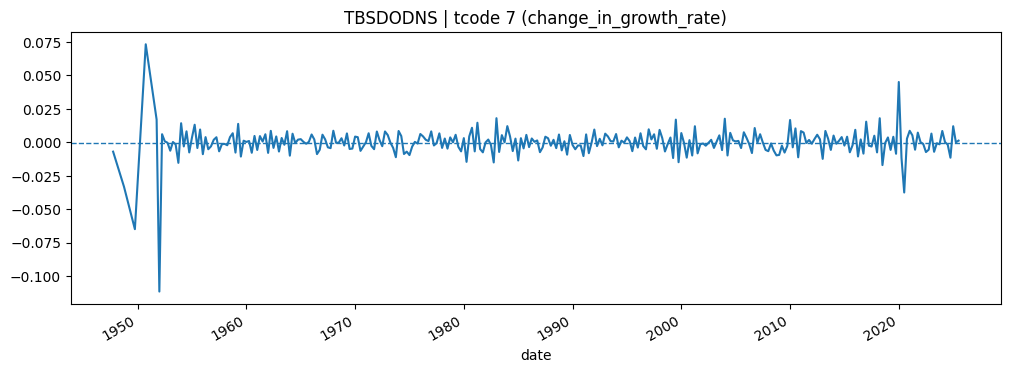

### Transformation Diagnostics

,label,n_obs,adf_pvalue,kpss_pvalue,arch_pvalue,stationarity_ok,variance_ok,autocorr_ok,overall_ok,recommended
tcode,,,,,,,,,,
1,level,302,1.000000e+00,0.01,6.411130e-55,0,0,0,0,0
2,first_difference,301,5.451324e-01,0.01,1.676404e-16,0,0,0,0,0
3,second_difference,300,1.144412e-06,0.10,4.128263e-17,1,0,0,0,1
4,log_level,302,1.384256e-01,0.01,5.974504e-55,0,0,0,0,0
5,log_first_difference,301,4.071285e-05,0.01,2.583373e-27,0,0,0,0,0
6,log_second_difference,300,3.612058e-14,0.10,6.252857e-09,1,0,0,0,0
7,change_in_growth_rate,300,2.307940e-14,0.10,8.296134e-09,1,0,0,0,0


### Suggested TCode

,label,overall_ok,stationarity_ok,variance_ok,autocorr_ok
tcode,,,,,
3,second_difference,0,1,0,0


Updated markdown overview: Data\analyzed\debt-persector.md


WindowsPath('C:/Users/olive/OneDrive/Dokumente/MASTER/MLFCS/MLFCS_RLMM_26/Data/analyzed/debt-persector.md')

In [ ]:
# =============================================================
# TEMPLATE EMPTY - READY TO USE
# =============================================================

SERIES_ID = "TBSDODNS"
CATEGORY = "debt-persector"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
 )
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
COMMENT = """
Nonfinancial Business; Debt Securities and Loans; Liability, Level
- per sector of TCMDO
Caveats:
- t5 or t6 again
- same tcode for all per sector
"""
TCODE1 = 5
TCODE2 = 6
append_series_to_markdown_overview(
    series_id=SERIES_ID,
    category=CATEGORY,
    description=COMMENT,
    tcode1=TCODE1,
    tcode2=TCODE2,
    obs_df=obs,
    meta=meta,
    release=release,
    vintages=vintages,
)

In [ ]:
# =============================================================
# TEMPLATE EMPTY - READY TO USE
# =============================================================

SERIES_ID = ""
CATEGORY = "none"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
 )
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
# COMMENT = """
# Why this series is relevant:
# - ...
# Caveats:
# - ...
# """
# TCODE1 = None
# TCODE2 = None
# append_series_to_markdown_overview(
#     series_id=SERIES_ID,
#     category=CATEGORY,
#     description=COMMENT,
#     tcode1=TCODE1,
#     tcode2=TCODE2,
#     obs_df=obs,
#     meta=meta,
#     release=release,
#     vintages=vintages,
# )

In [ ]:
# =============================================================
# TEMPLATE EMPTY - READY TO USE
# =============================================================

SERIES_ID = ""
CATEGORY = "none"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
 )
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
# COMMENT = """
# 
# - ...
# Caveats:
# - ...
# """
# TCODE1 = None
# TCODE2 = None
# append_series_to_markdown_overview(
#     series_id=SERIES_ID,
#     category=CATEGORY,
#     description=COMMENT,
#     tcode1=TCODE1,
#     tcode2=TCODE2,
#     obs_df=obs,
#     meta=meta,
#     release=release,
#     vintages=vintages,
# )

In [ ]:
# =============================================================
# TEMPLATE EMPTY - READY TO USE
# =============================================================

SERIES_ID = ""
CATEGORY = "none"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
 )
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
# COMMENT = """
# Why this series is relevant:
# - ...
# Caveats:
# - ...
# """
# TCODE1 = None
# TCODE2 = None
# append_series_to_markdown_overview(
#     series_id=SERIES_ID,
#     category=CATEGORY,
#     description=COMMENT,
#     tcode1=TCODE1,
#     tcode2=TCODE2,
#     obs_df=obs,
#     meta=meta,
#     release=release,
#     vintages=vintages,
# )

In [ ]:
# =============================================================
# TEMPLATE EMPTY - READY TO USE
# =============================================================

SERIES_ID = ""
CATEGORY = "none"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
 )
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
# COMMENT = """
# 
# - ...
# Caveats:
# - ...
# """
# TCODE1 = None
# TCODE2 = None
# append_series_to_markdown_overview(
#     series_id=SERIES_ID,
#     category=CATEGORY,
#     description=COMMENT,
#     tcode1=TCODE1,
#     tcode2=TCODE2,
#     obs_df=obs,
#     meta=meta,
#     release=release,
#     vintages=vintages,
# )

In [ ]:
# =============================================================
# TEMPLATE EMPTY - READY TO USE
# =============================================================

SERIES_ID = ""
CATEGORY = "none"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
 )
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
# COMMENT = """
# 
# - ...
# Caveats:
# - ...
# """
# TCODE1 = None
# TCODE2 = None
# append_series_to_markdown_overview(
#     series_id=SERIES_ID,
#     category=CATEGORY,
#     description=COMMENT,
#     tcode1=TCODE1,
#     tcode2=TCODE2,
#     obs_df=obs,
#     meta=meta,
#     release=release,
#     vintages=vintages,
# )

In [ ]:
# =============================================================
# TEMPLATE EMPTY - READY TO USE
# =============================================================

SERIES_ID = ""
CATEGORY = "none"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
 )
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
# COMMENT = """
# 
# - ...
# Caveats:
# - ...
# """
# TCODE1 = None
# TCODE2 = None
# append_series_to_markdown_overview(
#     series_id=SERIES_ID,
#     category=CATEGORY,
#     description=COMMENT,
#     tcode1=TCODE1,
#     tcode2=TCODE2,
#     obs_df=obs,
#     meta=meta,
#     release=release,
#     vintages=vintages,
# )

In [ ]:
# =============================================================
# TEMPLATE EMPTY - READY TO USE
# =============================================================

SERIES_ID = ""
CATEGORY = "none"

OBSERVATION_START = None
OBSERVATION_END   = None
TARGET_FREQUENCY  = None
UNITS             = None
AGG_METHOD        = None

meta = get_series_meta(SERIES_ID)
release = get_series_release(SERIES_ID)
obs = get_series_observations(
    SERIES_ID,
    observation_start=OBSERVATION_START,
    observation_end=OBSERVATION_END,
    frequency=TARGET_FREQUENCY,
    aggregation_method=AGG_METHOD,
    units=UNITS,
 )
vintages = get_series_vintages(SERIES_ID)
series = obs.set_index("date")["value"].sort_index()
series.name = SERIES_ID

show_core_summary(SERIES_ID, obs, meta, release, vintages)
missing_tbl = show_missing_report(series)

tcode_summary = review_tcodes(series, do_plots=True)
display(Markdown("### Transformation Diagnostics"))
display(
    tcode_summary[[
        "label", "n_obs", "adf_pvalue", "kpss_pvalue", "arch_pvalue",
        "stationarity_ok", "variance_ok", "autocorr_ok", "overall_ok", "recommended",
    ]]
)
display(Markdown("### Suggested TCode"))
display(tcode_summary[tcode_summary["recommended"] == 1][["label", "overall_ok", "stationarity_ok", "variance_ok", "autocorr_ok"]])

# Optional similarity step
# display(find_similar_in_fred_md(series, series_id=SERIES_ID, title=meta.get("title"), top_n=10))

# Optional markdown append step
# COMMENT = """
# 
# - ...
# Caveats:
# - ...
# """
# TCODE1 = None
# TCODE2 = None
# append_series_to_markdown_overview(
#     series_id=SERIES_ID,
#     category=CATEGORY,
#     description=COMMENT,
#     tcode1=TCODE1,
#     tcode2=TCODE2,
#     obs_df=obs,
#     meta=meta,
#     release=release,
#     vintages=vintages,
# )s